# Dataset Validation (v9_2)

Sanity-checks the output of `saas_generation_v9_2.py` before it goes to disaggregation and dbt.

Reads the two CSVs the generator produced, draws a handful of heatmaps and
charts, prints an LTV table, and runs a data integrity check.

If everything looks right here, the data is ready for disaggregation.
If something looks off, go back and tweak calibration_config_for_v9_2.py,
then re-run both scripts.

What is new in v9_2 (compared with the v8_2 notebook):
- Section 6 adds five checks for the new panel columns `customer_clv_24m`,
  `unit_clv_cac_ratio_24m` and `is_mature_24m`.
- Section 4 now expects a flat CAC line for every channel.
- Section 13 now checks price parity within a plan tier. The v9_2 generator
  charges every channel the same list price within a plan, so the band is
  1.05x instead of 1.5x.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

# Number of lifetime months that count toward CLV.
# Must match CLV_HORIZON_MONTHS in calibration_config_for_v9_2.py.
clv_month_count = 24

## Load data

Type the exact filename for each file the generator produced (with its
timestamp), for example:

```
saas_dataset_{datetime}.csv
cost_per_customer_{datetime}.csv
```

A full path also works if the files are not in the same folder as this
notebook.

In [2]:
# New import for subsequent runs during development
customer_month_panel_dataframe = pd.read_csv("df1.csv")
cost_per_customer_dataframe = pd.read_csv("df2.csv")

## Helper: retention percentage grid

Builds a cohort-month x lifetime-month grid of % of customers retained,
relative to each cohort's month-0 headcount. Used by all three retention
heatmaps below.

In [3]:
def build_retention_percentage_grid(source_dataframe, group_column_name=None, group_value=None) -> pd.DataFrame :
    """
    Build a cohort_month x lifetime_month grid of % of customers retained,
    relative to each cohort's month-0 headcount.

    Args:
        source_dataframe (pandas.DataFrame): the customer-month panel.
        group_column_name (str, optional): "channel" or "plan_tier", to
            slice the panel down to one segment before building the grid.
        group_value (str, optional): the specific channel or plan tier
            name to filter to, paired with group_column_name.

    Returns:
        pandas.DataFrame: cohort_month as the row index, lifetime_month as
            columns, retention percentage (0-100) as values.
    """
    working_dataframe = source_dataframe
    if group_column_name is not None:
        working_dataframe = working_dataframe[working_dataframe[group_column_name] == group_value]

    active_customer_counts = (
        working_dataframe
        .groupby(["cohort_month", "lifetime_month"])["customer_id"]
        .nunique()
        .reset_index(name="active_customer_count")
    )

    initial_customer_counts = (
        active_customer_counts[active_customer_counts["lifetime_month"] == 0]
        .set_index("cohort_month")["active_customer_count"]
    )

    active_customer_counts["initial_customer_count"] = active_customer_counts["cohort_month"].map(initial_customer_counts)
    active_customer_counts["retention_percentage"] = (
        active_customer_counts["active_customer_count"] / active_customer_counts["initial_customer_count"] * 100
    )

    retention_percentage_grid = active_customer_counts.pivot(
        index="cohort_month", columns="lifetime_month", values="retention_percentage"
    )
    return retention_percentage_grid

## 1. Retention % by channel

One heatmap panel per channel. Referral should visibly hold onto
customers longer than Ads. If every panel looks the same, or the pattern
is patchy instead of banded, the channel retention curves need a
second look.

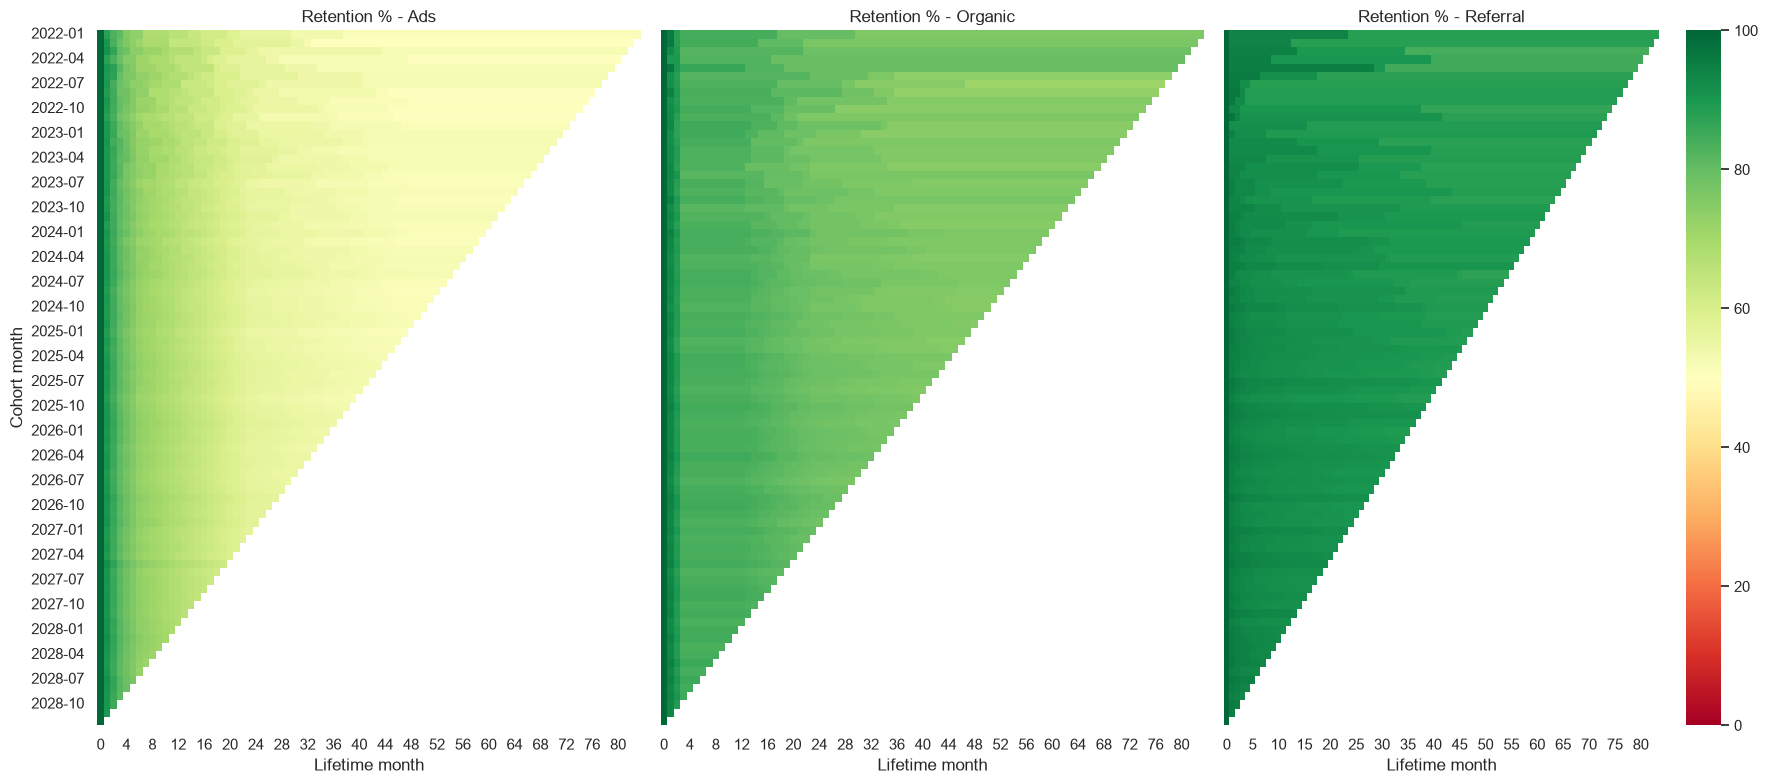

In [4]:
# 1. Retention percent by channel
channel_name_list = sorted(customer_month_panel_dataframe["channel"].unique())

figure, axis_list = plt.subplots(1, len(channel_name_list), figsize=(6 * len(channel_name_list), 8), sharey=True)

for axis, channel_name in zip(axis_list, channel_name_list):
    retention_percentage_grid_channel= build_retention_percentage_grid(
        customer_month_panel_dataframe, group_column_name="channel", group_value=channel_name
    )
    sns.heatmap(retention_percentage_grid_channel, ax=axis, cmap="RdYlGn", vmin=0, vmax=100, cbar=axis is axis_list[-1])
    axis.set_title(f"Retention % - {channel_name}")
    axis.set_xlabel("Lifetime month")
    axis.set_ylabel("Cohort month" if axis is axis_list[0] else "")

plt.tight_layout()
plt.show()

In [5]:
# 1. retention_percentage_grid_channel
retention_percentage_grid_channel.to_csv("helper_dfs/retention_pct_grid_channel.csv", index=False)
retention_percentage_grid_channel

lifetime_month,0,1,2,3,4,5,6,7,8,9,...,74,75,76,77,78,79,80,81,82,83
cohort_month,,,,,,,,,,,,,,,,,,,,,
2022-01,100.0,94.117647,94.117647,94.117647,94.117647,94.117647,94.117647,94.117647,94.117647,94.117647,...,88.235294,88.235294,88.235294,88.235294,88.235294,88.235294,88.235294,88.235294,88.235294,88.235294
2022-02,100.0,94.117647,94.117647,94.117647,94.117647,94.117647,94.117647,94.117647,94.117647,94.117647,...,88.235294,88.235294,88.235294,88.235294,88.235294,88.235294,88.235294,88.235294,88.235294,NaN
2022-03,100.0,94.736842,94.736842,94.736842,94.736842,94.736842,94.736842,94.736842,94.736842,94.736842,...,84.210526,84.210526,84.210526,84.210526,84.210526,84.210526,84.210526,84.210526,NaN,NaN
2022-04,100.0,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,90.000000,...,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,NaN,NaN,NaN
2022-05,100.0,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,...,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2028-08,100.0,95.362903,94.556452,93.750000,93.548387,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2028-09,100.0,94.736842,93.927126,93.117409,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2028-10,100.0,95.876289,95.051546,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Retention % by plan tier

Same idea, split by plan tier instead of channel. Enterprise should
retain noticeably better than Basic.

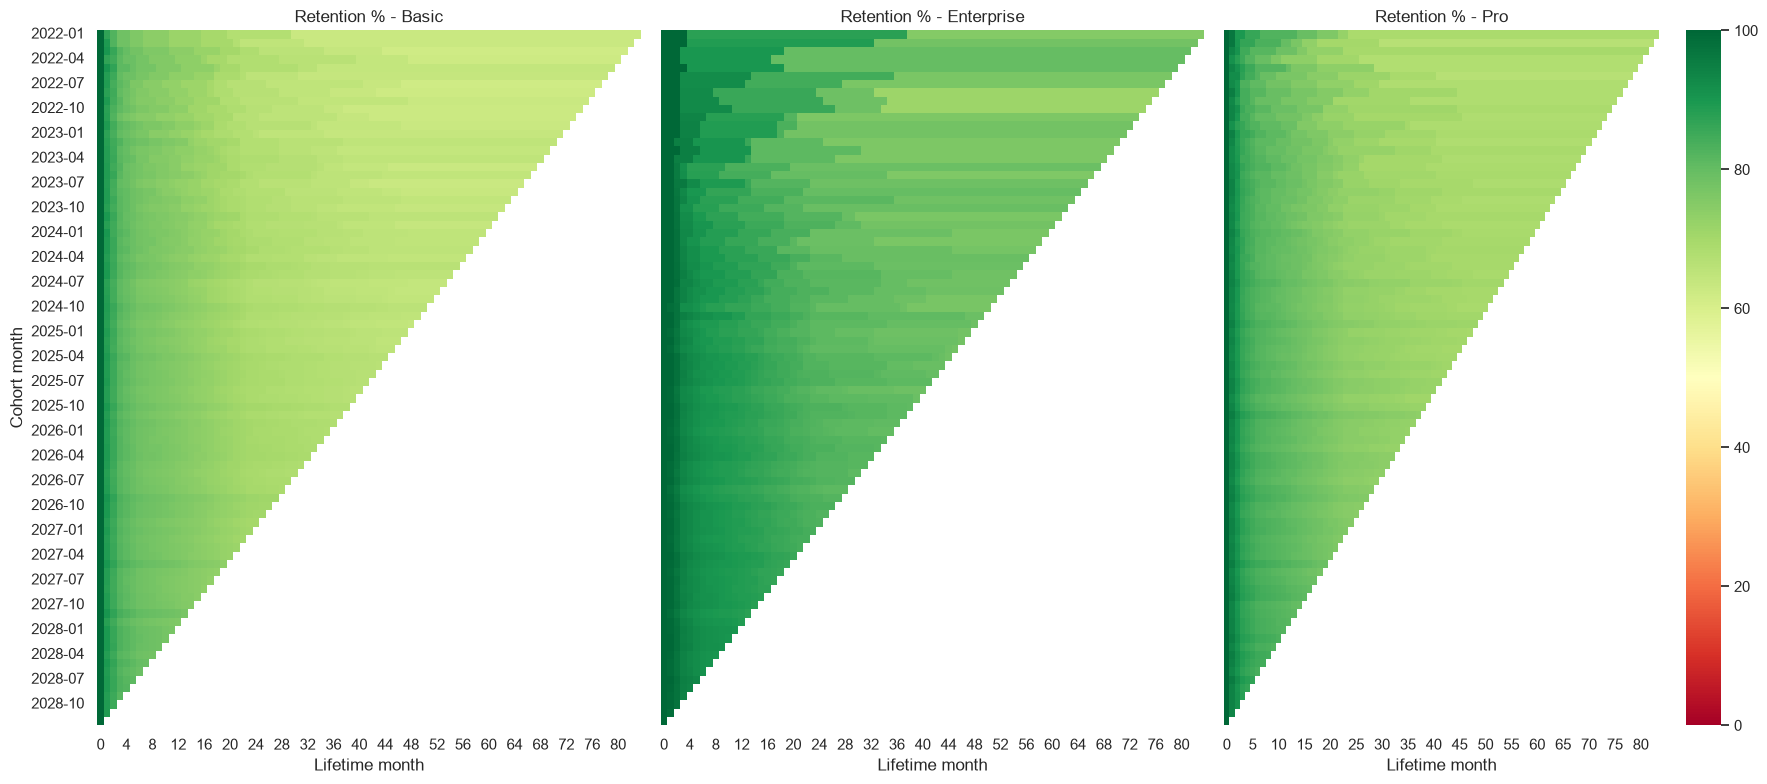

In [6]:
# 2. Retention percent by plan tier
plan_tier_name_list = sorted(customer_month_panel_dataframe["plan_tier"].unique())

figure, axis_list = plt.subplots(1, len(plan_tier_name_list), figsize=(6 * len(plan_tier_name_list), 8), sharey=True)

for axis, plan_tier_name in zip(axis_list, plan_tier_name_list):
    retention_percentage_grid_plan = build_retention_percentage_grid(
        customer_month_panel_dataframe, group_column_name="plan_tier", group_value=plan_tier_name
    )
    sns.heatmap(retention_percentage_grid_plan, ax=axis, cmap="RdYlGn", vmin=0, vmax=100, cbar=axis is axis_list[-1])
    axis.set_title(f"Retention % - {plan_tier_name}")
    axis.set_xlabel("Lifetime month")
    axis.set_ylabel("Cohort month" if axis is axis_list[0] else "")

plt.tight_layout()
plt.show()

In [7]:
# 2. retention_percentage_grid_plan
retention_percentage_grid_plan.to_csv("helper_dfs/retention_pct_grid_plan.csv", index=False)
retention_percentage_grid_plan

lifetime_month,0,1,2,3,4,5,6,7,8,9,...,74,75,76,77,78,79,80,81,82,83
cohort_month,,,,,,,,,,,,,,,,,,,,,
2022-01,100.0,96.551724,89.655172,89.655172,86.206897,86.206897,86.206897,82.758621,82.758621,82.758621,...,68.965517,68.965517,68.965517,68.965517,68.965517,68.965517,68.965517,68.965517,68.965517,68.965517
2022-02,100.0,96.666667,90.000000,86.666667,86.666667,86.666667,83.333333,83.333333,83.333333,83.333333,...,66.666667,66.666667,66.666667,66.666667,66.666667,66.666667,66.666667,66.666667,66.666667,NaN
2022-03,100.0,93.939394,90.909091,84.848485,84.848485,81.818182,81.818182,81.818182,81.818182,81.818182,...,69.696970,69.696970,69.696970,69.696970,69.696970,69.696970,69.696970,69.696970,NaN,NaN
2022-04,100.0,91.176471,88.235294,85.294118,82.352941,82.352941,79.411765,79.411765,79.411765,76.470588,...,67.647059,67.647059,67.647059,67.647059,67.647059,67.647059,67.647059,NaN,NaN,NaN
2022-05,100.0,94.117647,91.176471,88.235294,85.294118,85.294118,82.352941,82.352941,82.352941,82.352941,...,67.647059,67.647059,67.647059,67.647059,67.647059,67.647059,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2028-08,100.0,94.268775,90.909091,87.747036,86.561265,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2028-09,100.0,94.411178,91.217565,88.023952,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2028-10,100.0,94.478528,91.206544,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. MRR retention % (blended)

One heatmap, blended across every channel and plan tier. Values above
100% are expected here and there, where >100% means upsell revenue lifting the
cohort's bill past its month-0 starting point. The banding should
roughly mirror the customer-count retention heatmaps above.

In [8]:
def build_mrr_retention_percentage_grid(source_dataframe) -> pd.DataFrame:
    """
    Build a cohort_month x lifetime_month grid of % of MRR retained,
    relative to each cohort's month-0 total bill. Blended across every
    channel and plan tier.

    Args:
        source_dataframe (pandas.DataFrame): the customer-month panel.

    Returns:
        pandas.DataFrame: cohort_month as the row index, lifetime_month as
            columns, MRR retention percentage as values (can exceed 100
            where upsells outweigh churn).
    """
    mrr_by_cohort_lifetime = (
        source_dataframe
        .groupby(["cohort_month", "lifetime_month"])["mrr"]
        .sum()
        .reset_index(name="total_mrr")
    )
    initial_mrr_by_cohort = (
        mrr_by_cohort_lifetime[mrr_by_cohort_lifetime["lifetime_month"] == 0]
        .set_index("cohort_month")["total_mrr"]
    )
    mrr_by_cohort_lifetime["initial_mrr"] = mrr_by_cohort_lifetime["cohort_month"].map(initial_mrr_by_cohort)
    mrr_by_cohort_lifetime["mrr_retention_percentage"] = (
        mrr_by_cohort_lifetime["total_mrr"] / mrr_by_cohort_lifetime["initial_mrr"] * 100
    )
    mrr_retention_percentage_grid = mrr_by_cohort_lifetime.pivot(
        index="cohort_month", columns="lifetime_month", values="mrr_retention_percentage"
    )
    return mrr_retention_percentage_grid



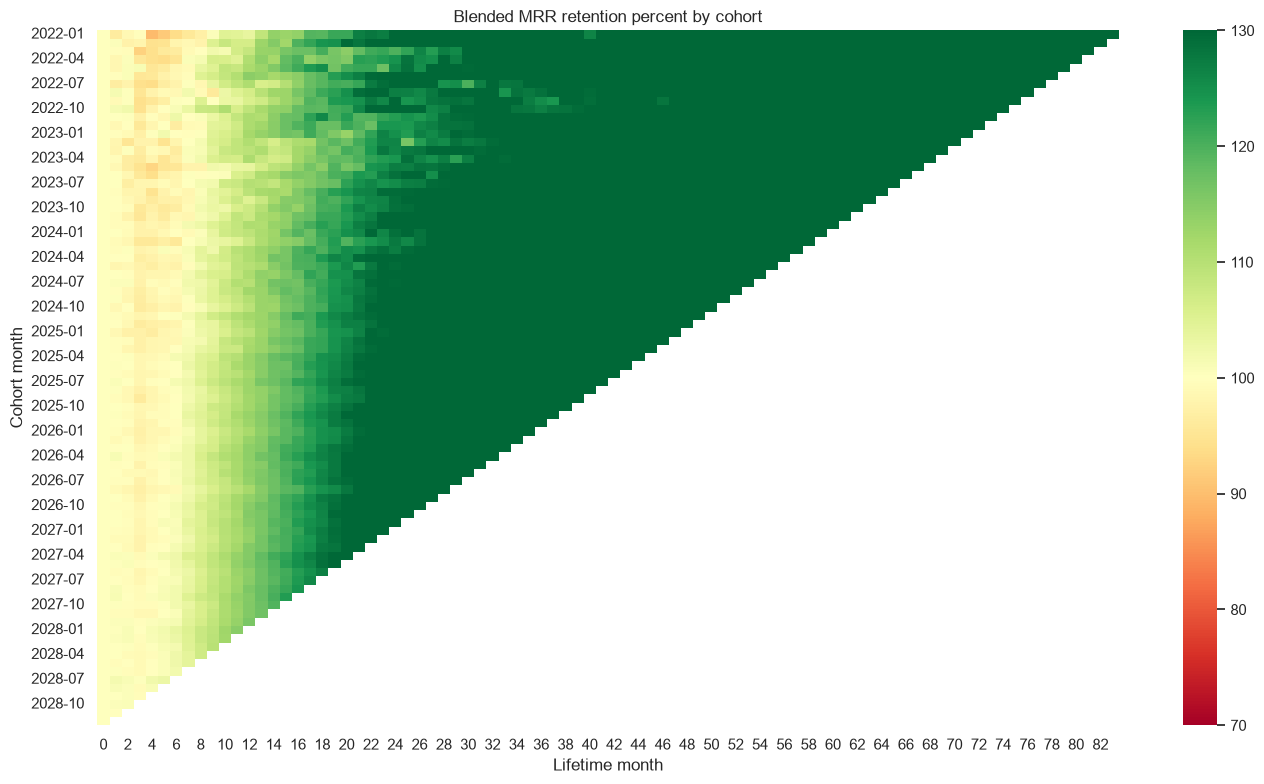

In [9]:
# 3. MRR retention percent and heatmap
mrr_retention_percentage_grid = build_mrr_retention_percentage_grid(customer_month_panel_dataframe)

# Fix sns limitation by overriding  vmin and vmax to accommodate large values
plt.figure(figsize=(14, 8))
sns.heatmap(mrr_retention_percentage_grid, cmap="RdYlGn", vmin=70, vmax=130, center=100)
plt.title("Blended MRR retention percent by cohort")
plt.xlabel("Lifetime month")
plt.ylabel("Cohort month")
plt.tight_layout()
plt.show()

In [10]:
# 3. Check mrr_retention_percentage_grid
mrr_retention_percentage_grid.to_csv("mrr_retention_pct_grid.csv", index=False)
mrr_retention_percentage_grid


lifetime_month,0,1,2,3,4,5,6,7,8,9,...,74,75,76,77,78,79,80,81,82,83
cohort_month,,,,,,,,,,,,,,,,,,,,,
2022-01,100.0,96.484225,98.717034,99.660485,89.527901,91.478580,93.833880,95.678577,97.151272,100.562796,...,143.092540,137.110024,142.156012,139.142186,141.369403,140.319703,139.011706,134.931405,138.409367,139.913883
2022-02,100.0,100.653199,97.536620,98.116729,94.601207,94.759962,98.075640,98.767563,97.868822,105.210901,...,144.415931,149.032902,142.681205,147.652044,147.227950,146.260727,148.601959,148.447064,144.512803,NaN
2022-03,100.0,99.698669,99.392896,92.496835,94.354688,96.015283,96.319724,98.924628,99.890486,102.111425,...,150.511140,149.462425,149.990226,149.624919,148.343181,149.589044,149.347913,149.926916,NaN,NaN
2022-04,100.0,98.578453,100.671741,95.546254,94.327833,93.882772,94.992171,100.921751,101.445998,106.288612,...,149.558865,146.890408,146.768488,152.593869,150.283547,148.004854,149.841290,NaN,NaN,NaN
2022-05,100.0,98.471038,100.706035,101.199234,95.415007,96.409875,98.504579,99.059066,103.406596,105.112067,...,152.910500,142.576270,148.049266,151.969900,149.499669,149.601852,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2028-08,100.0,101.153715,100.567670,99.246961,100.966970,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2028-09,100.0,100.140666,100.591125,99.300261,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2028-10,100.0,100.633441,100.784243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. CAC over time, by channel

A line chart, not a heatmap. In v9_2 every channel's CAC is flat over time
(`cac_trend` is 0 for all three channels). Each line should sit at its own
level with only a small random wiggle of about 3%. A slope, or a sudden
jump, means something changed in the config.

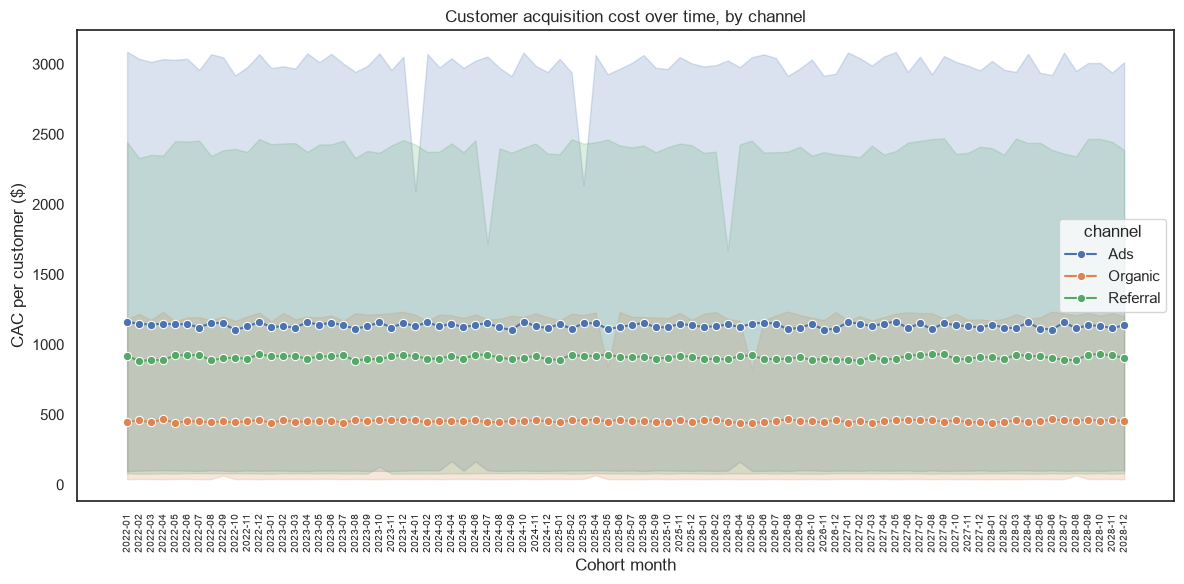

In [11]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=cost_per_customer_dataframe,
    x="cohort_month", y="cac_per_customer_dollars", hue="channel", marker="o"
)
plt.title("Customer acquisition cost over time, by channel")
plt.xlabel("Cohort month")
plt.ylabel("CAC per customer ($)")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

## 5. LTV table of most mature cohort

Uses the earliest cohort (the one with the longest observed history),
so the table has a full run of lifetime months rather than the 1-2
columns a like for a brand-new cohort.

Rows:
- **Retained** -> customers still active at that lifetime month
- **Lost** -> customers who churned during that specific month
- **LT months** -> running total of lifetime-months already used up by
  everyone who has churned so far
- **Total Months** -> running total of person-months of service the
  cohort has delivered so far
- **Average customer LTV** -> running total of revenue collected so far,
  divided by the cohort's starting headcount

In [12]:
# 5. LTV for most mature cohort
most_mature_cohort_month_text = customer_month_panel_dataframe["cohort_month"].min()
print(f"Building LTV table for the most mature cohort: {most_mature_cohort_month_text}")

most_mature_cohort_rows = customer_month_panel_dataframe[
    customer_month_panel_dataframe["cohort_month"] == most_mature_cohort_month_text
]

initial_cohort_customer_count = most_mature_cohort_rows[
    most_mature_cohort_rows["lifetime_month"] == 0
]["customer_id"].nunique()

retained_customers_by_month = most_mature_cohort_rows.groupby("lifetime_month")["customer_id"].nunique()
maximum_observed_lifetime_month = retained_customers_by_month.index.max()
full_lifetime_month_range = range(0, maximum_observed_lifetime_month + 1)
retained_customers_by_month = retained_customers_by_month.reindex(full_lifetime_month_range, fill_value=0)

# Lost this month = drop from the previous month's retained count.
# Nobody is "lost" at month 0, they just joined.
lost_customers_by_month = -retained_customers_by_month.diff().fillna(0).astype(int)
lost_customers_by_month.iloc[0] = 0

# A customer lost during month m had m completed months of tenure
# (months 0 through m-1), so their contribution to "LT months" is m.
lifetime_months_of_lost_customers_by_month = lost_customers_by_month.index.to_series() * lost_customers_by_month
cumulative_lifetime_months_of_lost_customers = lifetime_months_of_lost_customers_by_month.cumsum()

cumulative_total_months_delivered = retained_customers_by_month.cumsum()

mrr_by_month = most_mature_cohort_rows.groupby("lifetime_month")["mrr"].sum().reindex(full_lifetime_month_range, fill_value=0)
cumulative_average_customer_ltv = mrr_by_month.cumsum() / initial_cohort_customer_count

ltv_table_dataframe = pd.DataFrame({
    "Retained": retained_customers_by_month,
    "Lost": lost_customers_by_month,
    "LT months": cumulative_lifetime_months_of_lost_customers,
    "Total Months": cumulative_total_months_delivered,
    "Average customer LTV": cumulative_average_customer_ltv.round(2),
}).T
ltv_table_dataframe.columns.name = "Lifetime month"
ltv_table_dataframe

Building LTV table for the most mature cohort: 2022-01


Lifetime month,0,1,2,3,4,5,6,7,8,9,...,74,75,76,77,78,79,80,81,82,83
Retained,83.00,76.0,72.00,70.00,68.00,67.00,67.00,65.0,65.00,65.00,...,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00
Lost,0.00,7.0,4.00,2.00,2.00,1.00,0.00,2.0,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
LT months,0.00,7.0,15.00,21.00,29.00,34.00,34.00,48.0,48.00,48.00,...,271.00,271.00,271.00,271.00,271.00,271.00,271.00,271.00,271.00,271.00
Total Months,83.00,159.0,231.00,301.00,369.00,436.00,503.00,568.0,633.00,698.00,...,4396.00,4451.00,4506.00,4561.00,4616.00,4671.00,4726.00,4781.00,4836.00,4891.00
Average customer LTV,90.49,177.8,267.13,357.31,438.33,521.11,606.02,692.6,780.51,871.51,...,8677.31,8801.38,8930.02,9055.93,9183.86,9310.83,9436.63,9558.73,9683.97,9810.58


## 6. Data integrity check

A pass/fail list.  
Checks for missing values, negative numbers, retention that increases instead of decreasing, the triangular
right-censored shape, and a few consistency checks between the two files.

v9_2 adds five checks (9 to 13): the new columns exist, `customer_clv_24m` equals the first 24 months of MRR,
the CLV and CAC columns are constant within a customer, the ratio column matches CLV divided by CAC,
and `is_mature_24m` follows the cohort age rule.

In [13]:
integrity_check_results = []


def record_integrity_check_result(check_description_text, check_passed_boolean, details_text=""):
    """Append one check's outcome to the running results list."""
    integrity_check_results.append((check_description_text, check_passed_boolean, details_text))


# 1. No missing values in either file ----------------------------------
customer_panel_missing_value_count = customer_month_panel_dataframe.isna().sum().sum()
cost_table_missing_value_count = cost_per_customer_dataframe.isna().sum().sum()
record_integrity_check_result(
    "No missing values in either file",
    customer_panel_missing_value_count == 0 and cost_table_missing_value_count == 0,
    f"{customer_panel_missing_value_count} missing in panel, {cost_table_missing_value_count} missing in cost table",
)

# 2. No negative MRR ------------------------------------------------------
negative_mrr_row_count = (customer_month_panel_dataframe["mrr"] < 0).sum()
record_integrity_check_result(
    "No negative MRR values",
    negative_mrr_row_count == 0,
    f"{negative_mrr_row_count} rows with negative MRR",
)

# 3. No negative CAC -------------------------------------------------------
negative_cac_row_count = (cost_per_customer_dataframe["cac_per_customer_dollars"] < 0).sum()
record_integrity_check_result(
    "No negative CAC values",
    negative_cac_row_count == 0,
    f"{negative_cac_row_count} rows with negative CAC",
)

# 4. Retention never increases within a cohort -----------------------------
blended_retention_grid = build_retention_percentage_grid(customer_month_panel_dataframe)
retention_increase_detected = (blended_retention_grid.diff(axis=1) > 0.01).any().any()
record_integrity_check_result(
    "Retention never increases within a cohort",
    not retention_increase_detected,
    "Found a month-over-month increase" if retention_increase_detected else "All cohorts non-increasing",
)

# 5. Triangular shape: newer cohorts show fewer completed months ----------
maximum_lifetime_month_by_cohort = (
    customer_month_panel_dataframe.groupby("cohort_month")["lifetime_month"].max().sort_index()
)
triangular_shape_confirmed = maximum_lifetime_month_by_cohort.is_monotonic_decreasing
record_integrity_check_result(
    "Triangular shape: newer cohorts show fewer completed months",
    triangular_shape_confirmed,
    "Confirmed triangular" if triangular_shape_confirmed else "Max lifetime month does not decrease monotonically toward the newest cohort",
)

# 6. calendar_month always equals cohort_month + lifetime_month -----------
calendar_month_check_dataframe = customer_month_panel_dataframe.copy()
calendar_month_check_dataframe["expected_calendar_month"] = (
    pd.PeriodIndex(calendar_month_check_dataframe["cohort_month"], freq="M")
    + calendar_month_check_dataframe["lifetime_month"]
).astype(str)
calendar_month_mismatch_count = (
    calendar_month_check_dataframe["calendar_month"] != calendar_month_check_dataframe["expected_calendar_month"]
).sum()
record_integrity_check_result(
    "calendar_month always equals cohort_month + lifetime_month",
    calendar_month_mismatch_count == 0,
    f"{calendar_month_mismatch_count} mismatched rows",
)

# 7. No duplicate customer-month rows --------------------------------------
duplicate_customer_month_row_count = customer_month_panel_dataframe.duplicated(subset=["customer_id", "calendar_month"]).sum()
record_integrity_check_result(
    "No duplicate customer-month rows",
    duplicate_customer_month_row_count == 0,
    f"{duplicate_customer_month_row_count} duplicate rows",
)

# 8. is_active is always True (panel only stores active months) -----------
inactive_row_count = (~customer_month_panel_dataframe["is_active"]).sum()
record_integrity_check_result(
    "is_active is True on every row",
    inactive_row_count == 0,
    f"{inactive_row_count} rows marked inactive",
)

# ---------------------------------------------------------------------
# v9_2 checks (9 to 13)
# ---------------------------------------------------------------------

# 9. The v9_2 columns are present -------------------------------------------
v9_2_required_column_name_list = ["customer_clv_24m", "customer_cac", "unit_clv_cac_ratio_24m", "is_mature_24m"]
missing_v9_2_column_name_list = [
    column_name for column_name in v9_2_required_column_name_list
    if column_name not in customer_month_panel_dataframe.columns
]
record_integrity_check_result(
    "v9_2 columns are present in the panel",
    len(missing_v9_2_column_name_list) == 0,
    f"Missing: {missing_v9_2_column_name_list}" if missing_v9_2_column_name_list else "All four columns present",
)

if not missing_v9_2_column_name_list:
    # 10. customer_clv_24m equals the first 24 months of MRR ------------------
    recomputed_clv_by_customer = (
        customer_month_panel_dataframe[customer_month_panel_dataframe["lifetime_month"] < clv_month_count]
        .groupby("customer_id")["mrr"].sum()
    )
    stored_clv_by_customer = customer_month_panel_dataframe.groupby("customer_id")["customer_clv_24m"].first()
    largest_clv_difference_dollars = (stored_clv_by_customer - recomputed_clv_by_customer).abs().max()
    record_integrity_check_result(
        f"customer_clv_24m equals MRR summed over lifetime months 0 to {clv_month_count - 1}",
        largest_clv_difference_dollars <= 0.02,
        f"Largest difference: ${largest_clv_difference_dollars:.4f}",
    )

    # 11. CLV and CAC are constant within a customer --------------------------
    distinct_value_count_by_customer = (
        customer_month_panel_dataframe.groupby("customer_id")[["customer_clv_24m", "customer_cac"]].nunique()
    )
    customers_with_changing_values = int((distinct_value_count_by_customer.max(axis=1) > 1).sum())
    record_integrity_check_result(
        "customer_clv_24m and customer_cac are constant within each customer",
        customers_with_changing_values == 0,
        f"{customers_with_changing_values} customers with more than one value",
    )

    # 12. The ratio column equals CLV divided by CAC --------------------------
    largest_ratio_difference = (
        customer_month_panel_dataframe["customer_clv_24m"] / customer_month_panel_dataframe["customer_cac"]
        - customer_month_panel_dataframe["unit_clv_cac_ratio_24m"]
    ).abs().max()
    record_integrity_check_result(
        "unit_clv_cac_ratio_24m equals customer_clv_24m / customer_cac",
        largest_ratio_difference <= 0.0001,
        f"Largest difference: {largest_ratio_difference:.6f}",
    )

    # 13. is_mature_24m follows the cohort age rule ---------------------------
    last_calendar_month_ordinal = pd.Period(customer_month_panel_dataframe["calendar_month"].max(), freq="M").ordinal
    maturity_flag_by_cohort = customer_month_panel_dataframe.groupby("cohort_month")["is_mature_24m"].agg(["min", "max"])
    expected_maturity_flag_by_cohort = pd.Series({
        cohort_month_text: (last_calendar_month_ordinal - pd.Period(cohort_month_text, freq="M").ordinal) >= clv_month_count - 1
        for cohort_month_text in maturity_flag_by_cohort.index
    })
    flag_is_constant_within_cohort = bool((maturity_flag_by_cohort["min"] == maturity_flag_by_cohort["max"]).all())
    flag_matches_age_rule = bool((maturity_flag_by_cohort["max"] == expected_maturity_flag_by_cohort).all())
    record_integrity_check_result(
        f"is_mature_24m is True only for cohorts observed at least {clv_month_count} months",
        flag_is_constant_within_cohort and flag_matches_age_rule,
        f"{int(expected_maturity_flag_by_cohort.sum())} mature cohorts expected, "
        f"{int(maturity_flag_by_cohort['max'].sum())} flagged mature",
    )

print("DATA INTEGRITY RESULTS")
print("=" * 60)
for check_description_text, check_passed_boolean, details_text in integrity_check_results:
    status_label = "PASS" if check_passed_boolean else "FAIL"
    print(f"[{status_label}] {check_description_text}")
    if not check_passed_boolean:
        print(f"       -> {details_text}")

all_checks_passed = all(result[1] for result in integrity_check_results)
print("=" * 60)
print("Overall: ALL CHECKS PASSED" if all_checks_passed else "Overall: SOME CHECKS FAILED, review details above")

DATA INTEGRITY RESULTS
[PASS] No missing values in either file
[PASS] No negative MRR values
[PASS] No negative CAC values
[PASS] Retention never increases within a cohort
[PASS] Triangular shape: newer cohorts show fewer completed months
[PASS] calendar_month always equals cohort_month + lifetime_month
[PASS] No duplicate customer-month rows
[PASS] is_active is True on every row
[PASS] v9_2 columns are present in the panel
[PASS] customer_clv_24m equals MRR summed over lifetime months 0 to 23
[PASS] customer_clv_24m and customer_cac are constant within each customer
[PASS] unit_clv_cac_ratio_24m equals customer_clv_24m / customer_cac
[PASS] is_mature_24m is True only for cohorts observed at least 24 months
Overall: ALL CHECKS PASSED


## 7. CLV:CAC ratio

CLV is the revenue one new customer brings in over their first N months of life. CAC is what it costs to acquire that customer.

The old version divided all revenue collected so far by all customers. That mixes customers who have paid for 24 months with customers who joined last month, yet every customer carries the full acquisition cost. The ratios came out too low.

This version builds CLV one month of life at a time. For month 1 of life, it uses every cohort that has reached month 1. For month 2, every cohort that has reached month 2. It continues up to N months. A young cohort only counts for the months it has lived through.

N (`clv_month_count`) is a choice. A longer window gives a higher CLV. State the window whenever the ratio is quoted.

In [14]:
def build_clv_cac_ratio_table(customer_month_panel_dataframe, cost_per_customer_dataframe,
                              group_column_name_list=("channel",), clv_month_count=24,
                              cohort_month_text_filter=None) -> pd.DataFrame:
    """
    Build a CLV:CAC ratio table, one row per group (for example, per channel).

    CLV is the revenue one new customer brings in over their first
    clv_month_count months of life. It is built one month of life at a time.
    For each month of life, take every cohort that has reached that month,
    add up their revenue in that month, and divide by how many customers
    those cohorts started with. Adding up the monthly averages gives the CLV.

    A young cohort only counts for the months it has actually lived through.
    It is never compared against its full acquisition cost with only a few
    months of revenue behind it.

    CAC is total acquisition cost divided by total customers acquired.

    Args:
        customer_month_panel_dataframe (pandas.DataFrame): the customer-month panel.
        cost_per_customer_dataframe (pandas.DataFrame): the cost-per-customer table.
        group_column_name_list (list of str): columns to group by, for
            example ["channel"] or ["channel", "plan_tier"].
        clv_month_count (int): how many months of a customer's life count
            toward CLV.
        cohort_month_text_filter (str, optional): keep only this cohort,
            for example "2022-01". CLV and CAC both use only this cohort.

    Returns:
        pandas.DataFrame: one row per group with clv_dollars,
            blended_cac_dollars, and clv_to_cac_ratio.
    """
    group_columns = list(group_column_name_list)

    if customer_month_panel_dataframe["lifetime_month"].max() < clv_month_count - 1:
        raise ValueError(
            f"The panel only tracks {customer_month_panel_dataframe['lifetime_month'].max() + 1} "
            f"lifetime months. Lower clv_month_count from {clv_month_count}."
        )

    # How many lifetime months each cohort has lived through by the end of the data.
    # Convert the date string to a calendar month object to enable subtraction
    last_calendar_month_number = pd.Period(
        customer_month_panel_dataframe["calendar_month"].max(), freq="M"
    ).ordinal
    print ("last_calendar_month_ordinal \n", last_calendar_month_ordinal)
    cohort_months_observable_lookup = {
        cohort_month_text: last_calendar_month_number - pd.Period(cohort_month_text, freq="M").ordinal
        for cohort_month_text in customer_month_panel_dataframe["cohort_month"].unique()
    }
    print ("\n\ncohort_months_observable_lookup \n", cohort_months_observable_lookup)

    panel_dataframe = customer_month_panel_dataframe
    cost_dataframe = cost_per_customer_dataframe
    if cohort_month_text_filter is not None:
        panel_dataframe = panel_dataframe[panel_dataframe["cohort_month"] == cohort_month_text_filter]
        cost_dataframe = cost_dataframe[cost_dataframe["cohort_month"] == cohort_month_text_filter]

    starting_customer_table = (
        panel_dataframe[panel_dataframe["lifetime_month"] == 0]
        .groupby(group_columns + ["cohort_month"])["customer_id"]
        .nunique()
        .reset_index(name="starting_customer_count")
    )
    starting_customer_table["months_observable"] = starting_customer_table["cohort_month"].map(
        cohort_months_observable_lookup
    )
    print ("\n\nstarting_customer_table \n", starting_customer_table)

    revenue_table = (
        panel_dataframe
        .groupby(group_columns + ["lifetime_month"])["mrr"]
        .sum()
        .reset_index(name="revenue_dollars")
    )
    print ("\n\nrevenue_table \n", revenue_table)

    monthly_average_revenue_series_list = []
    for lifetime_month_number in range(clv_month_count): 
        cohorts_that_reached_month = starting_customer_table[
            starting_customer_table["months_observable"] >= lifetime_month_number
        ]  #filter out only cohorts that reach 24 months
        starting_customers_by_group = cohorts_that_reached_month.groupby(group_columns)["starting_customer_count"].sum() #denominator saved to memory 24 times when clv_month_count is 24, group is `channel`, `plan_tier` or both
        revenue_by_group = (
            revenue_table[revenue_table["lifetime_month"] == lifetime_month_number]
            .set_index(group_columns)["revenue_dollars"]
        ) # numerator saved to memory 24 times when clv_month_count is 24, group is `channel`, `plan_tier` or both
        monthly_average_revenue_series_list.append(
            (revenue_by_group / starting_customers_by_group).fillna(0)
        )

    print ("\n\nmonthly_average_revenue_series_list \n", monthly_average_revenue_series_list)

    clv_series = pd.concat(monthly_average_revenue_series_list, axis=1).sum(axis=1)
    print ("\n\nclv_series \n", clv_series)

    cost_totals = cost_dataframe.groupby(group_columns).agg(
        total_acquisition_cost_dollars=("total_acquisition_cost_dollars", "sum"),
        customers_acquired=("new_customers", "sum"),
    )
    print ("\n\ncost_totals \n", cost_totals)
    
    blended_cac_series = cost_totals["total_acquisition_cost_dollars"] / cost_totals["customers_acquired"]
    print ("\n\nblended_cac_series \n", blended_cac_series)

    clv_cac_table = pd.DataFrame({"clv_dollars": clv_series, "blended_cac_dollars": blended_cac_series})
    clv_cac_table["clv_to_cac_ratio"] = clv_cac_table["clv_dollars"] / clv_cac_table["blended_cac_dollars"]
    return clv_cac_table.round(2)

In [15]:
# 7a. CLV:CAC ratio by channel
# clv_month_count is set in the Setup cell at the top of the notebook.

clv_cac_ratio_table = build_clv_cac_ratio_table(
    customer_month_panel_dataframe, cost_per_customer_dataframe,
    group_column_name_list=["channel"], clv_month_count=clv_month_count,
)

print(f"CLV:CAC ratio, CLV counted over the first {clv_month_count} months (3:1 is the usual healthy minimum)")
for channel_name, row in clv_cac_ratio_table.iterrows():
    status_label = "OK" if row["clv_to_cac_ratio"] >= 3 else "BELOW 3:1 benchmark"
    print(f"{channel_name}: {row['clv_to_cac_ratio']}:1 -- {status_label}")

clv_cac_ratio_table.to_csv("helper_dfs/clv_cac_by_channel.csv")
clv_cac_ratio_table

last_calendar_month_ordinal 
 707


cohort_months_observable_lookup 
 {'2022-01': 83, '2022-02': 82, '2022-03': 81, '2022-04': 80, '2022-05': 79, '2022-06': 78, '2022-07': 77, '2022-08': 76, '2022-09': 75, '2022-10': 74, '2022-11': 73, '2022-12': 72, '2023-01': 71, '2023-02': 70, '2023-03': 69, '2023-04': 68, '2023-05': 67, '2023-06': 66, '2023-07': 65, '2023-08': 64, '2023-09': 63, '2023-10': 62, '2023-11': 61, '2023-12': 60, '2024-01': 59, '2024-02': 58, '2024-03': 57, '2024-04': 56, '2024-05': 55, '2024-06': 54, '2024-07': 53, '2024-08': 52, '2024-09': 51, '2024-10': 50, '2024-11': 49, '2024-12': 48, '2025-01': 47, '2025-02': 46, '2025-03': 45, '2025-04': 44, '2025-05': 43, '2025-06': 42, '2025-07': 41, '2025-08': 40, '2025-09': 39, '2025-10': 38, '2025-11': 37, '2025-12': 36, '2026-01': 35, '2026-02': 34, '2026-03': 33, '2026-04': 32, '2026-05': 31, '2026-06': 30, '2026-07': 29, '2026-08': 28, '2026-09': 27, '2026-10': 26, '2026-11': 25, '2026-12': 24, '2027-01': 23, '2027-02': 22,

,clv_dollars,blended_cac_dollars,clv_to_cac_ratio
channel,,,
Ads,2879.15,654.87,4.40
Organic,3517.05,263.24,13.36
Referral,4049.38,535.42,7.56


In [16]:
# 7b. CLV:CAC ratio by channel and plan tier
clv_cac_ratio_table_by_segment = build_clv_cac_ratio_table(
    customer_month_panel_dataframe, cost_per_customer_dataframe,
    group_column_name_list=["channel", "plan_tier"], clv_month_count=clv_month_count,
)

print(f"CLV:CAC ratio by channel and plan tier, CLV counted over the first {clv_month_count} months")
for (channel_name, plan_tier_name), row in clv_cac_ratio_table_by_segment.iterrows():
    status_label = "OK" if row["clv_to_cac_ratio"] >= 3 else "BELOW 3:1 benchmark"
    print(f"{channel_name:10s}{plan_tier_name:12s}{row['clv_to_cac_ratio']}:1 -- {status_label}")

clv_cac_ratio_table_by_segment.to_csv("helper_dfs/clv_cac_by_channel_and_plan_tier.csv")
clv_cac_ratio_table_by_segment

last_calendar_month_ordinal 
 707


cohort_months_observable_lookup 
 {'2022-01': 83, '2022-02': 82, '2022-03': 81, '2022-04': 80, '2022-05': 79, '2022-06': 78, '2022-07': 77, '2022-08': 76, '2022-09': 75, '2022-10': 74, '2022-11': 73, '2022-12': 72, '2023-01': 71, '2023-02': 70, '2023-03': 69, '2023-04': 68, '2023-05': 67, '2023-06': 66, '2023-07': 65, '2023-08': 64, '2023-09': 63, '2023-10': 62, '2023-11': 61, '2023-12': 60, '2024-01': 59, '2024-02': 58, '2024-03': 57, '2024-04': 56, '2024-05': 55, '2024-06': 54, '2024-07': 53, '2024-08': 52, '2024-09': 51, '2024-10': 50, '2024-11': 49, '2024-12': 48, '2025-01': 47, '2025-02': 46, '2025-03': 45, '2025-04': 44, '2025-05': 43, '2025-06': 42, '2025-07': 41, '2025-08': 40, '2025-09': 39, '2025-10': 38, '2025-11': 37, '2025-12': 36, '2026-01': 35, '2026-02': 34, '2026-03': 33, '2026-04': 32, '2026-05': 31, '2026-06': 30, '2026-07': 29, '2026-08': 28, '2026-09': 27, '2026-10': 26, '2026-11': 25, '2026-12': 24, '2027-01': 23, '2027-02': 22,

clv_dollars  blended_cac_dollars  clv_to_cac_ratio
channel  plan_tier                                                     
Ads      Basic            325.81                99.84              3.26
         Enterprise     14540.37              3001.07              4.85
         Pro             1155.41               300.30              3.85
Organic  Basic            399.42                39.88             10.02
         Enterprise     17728.02              1201.69             14.75
         Pro             1409.28               119.88             11.76
Referral Basic            446.31                79.95              5.58
         Enterprise     20159.60              2403.27              8.39
         Pro             1609.07               239.43              6.72

In [17]:
# 7c. CLV:CAC ratio by channel, oldest cohort only
clv_cac_ratio_table_most_mature = build_clv_cac_ratio_table(
    customer_month_panel_dataframe, cost_per_customer_dataframe,
    group_column_name_list=["channel"], clv_month_count=clv_month_count,
    cohort_month_text_filter=most_mature_cohort_month_text,
)

print(f"CLV:CAC ratio for the {most_mature_cohort_month_text} cohort, CLV counted over the first {clv_month_count} months")
for channel_name, row in clv_cac_ratio_table_most_mature.iterrows():
    status_label = "OK" if row["clv_to_cac_ratio"] >= 3 else "BELOW 3:1 benchmark"
    print(f"{channel_name}: {row['clv_to_cac_ratio']}:1 -- {status_label}")

clv_cac_ratio_table_most_mature

last_calendar_month_ordinal 
 707


cohort_months_observable_lookup 
 {'2022-01': 83, '2022-02': 82, '2022-03': 81, '2022-04': 80, '2022-05': 79, '2022-06': 78, '2022-07': 77, '2022-08': 76, '2022-09': 75, '2022-10': 74, '2022-11': 73, '2022-12': 72, '2023-01': 71, '2023-02': 70, '2023-03': 69, '2023-04': 68, '2023-05': 67, '2023-06': 66, '2023-07': 65, '2023-08': 64, '2023-09': 63, '2023-10': 62, '2023-11': 61, '2023-12': 60, '2024-01': 59, '2024-02': 58, '2024-03': 57, '2024-04': 56, '2024-05': 55, '2024-06': 54, '2024-07': 53, '2024-08': 52, '2024-09': 51, '2024-10': 50, '2024-11': 49, '2024-12': 48, '2025-01': 47, '2025-02': 46, '2025-03': 45, '2025-04': 44, '2025-05': 43, '2025-06': 42, '2025-07': 41, '2025-08': 40, '2025-09': 39, '2025-10': 38, '2025-11': 37, '2025-12': 36, '2026-01': 35, '2026-02': 34, '2026-03': 33, '2026-04': 32, '2026-05': 31, '2026-06': 30, '2026-07': 29, '2026-08': 28, '2026-09': 27, '2026-10': 26, '2026-11': 25, '2026-12': 24, '2027-01': 23, '2027-02': 22,

,clv_dollars,blended_cac_dollars,clv_to_cac_ratio
channel,,,
Ads,2026.49,458.55,4.42
Organic,2283.84,159.85,14.29
Referral,3193.69,413.90,7.72


## 8. Net Revenue Retention (NRR) by calendar month

In [18]:
# 8. Net Revenue Retention (NRR) by calendar month

def build_monthly_net_revenue_retention_table(customer_month_panel_dataframe) -> pd.DataFrame:
    """
    Build a monthly NRR series.

    Compares the SAME set of customers across two consecutive calendar
    months, e.g., customers active in month M-1, and tracks what happened
    to their combined MRR by month M. New signups in month M are
    excluded from both sides of the ratio; this isolates expansion,
    contraction, and churn among the existing base.

    NRR_M = (month M MRR from month-M-1's customers) / (month M-1 MRR
            from those same customers) * 100
    """
    mrr_by_customer_month = customer_month_panel_dataframe.pivot_table(
        index="customer_id", columns="calendar_month", values="mrr", aggfunc="sum"
    )
    sorted_calendar_month_columns = sorted(mrr_by_customer_month.columns)

    monthly_nrr_lookup = {}
    for month_index in range(1, len(sorted_calendar_month_columns)):
        previous_month_text = sorted_calendar_month_columns[month_index - 1]
        current_month_text = sorted_calendar_month_columns[month_index]

        customers_active_in_previous_month = mrr_by_customer_month[previous_month_text].dropna().index
        starting_mrr_total = mrr_by_customer_month.loc[customers_active_in_previous_month, previous_month_text].sum()
        retained_mrr_total = mrr_by_customer_month.loc[customers_active_in_previous_month, current_month_text].fillna(0).sum()

        monthly_nrr_lookup[current_month_text] = (retained_mrr_total / starting_mrr_total) * 100

    monthly_nrr_series = pd.Series(monthly_nrr_lookup).sort_index()
    monthly_nrr_series.index.name = "calendar_month"
    monthly_nrr_series.name = "nrr_percentage"
    return monthly_nrr_series



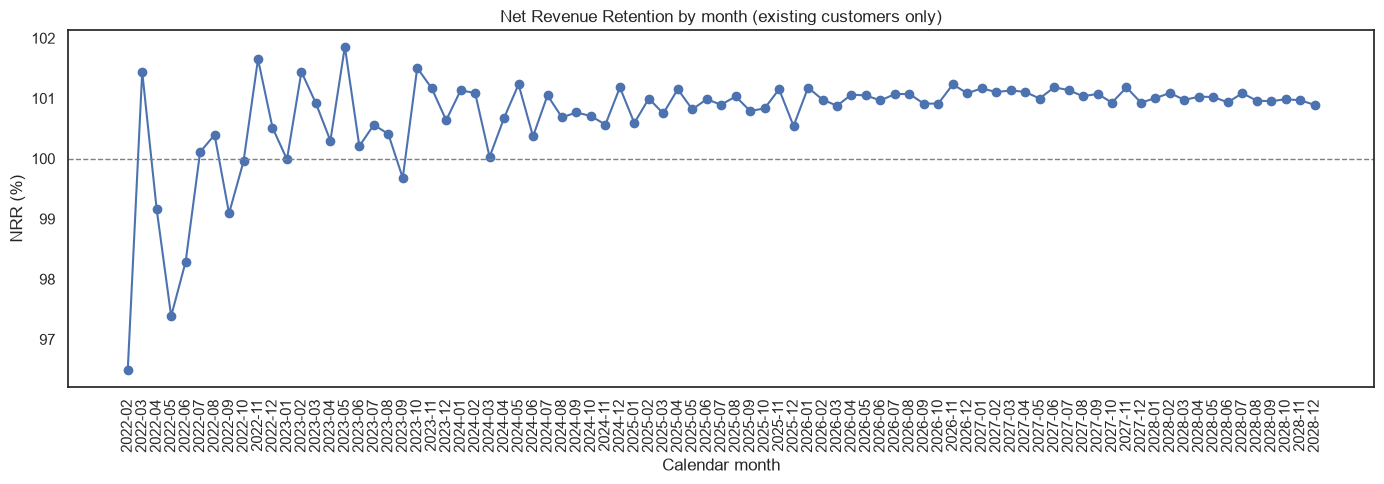

calendar_month
2022-02     96.484225
2022-03    101.441036
2022-04     99.156907
2022-05     97.384233
2022-06     98.288092
              ...    
2028-08    100.961260
2028-09    100.953119
2028-10    100.985412
2028-11    100.968712
2028-12    100.891228
Name: nrr_percentage, Length: 83, dtype: float64

In [19]:
# 8. Net Revenue Retention (NRR) by calendar month
monthly_nrr_series = build_monthly_net_revenue_retention_table(customer_month_panel_dataframe)

plt.figure(figsize=(14, 5))
plt.plot(monthly_nrr_series.index.astype(str), monthly_nrr_series.values, marker="o")
plt.axhline(100, color="gray", linestyle="--", linewidth=1)
plt.title("Net Revenue Retention by month (existing customers only)")
plt.xlabel("Calendar month")
plt.ylabel("NRR (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

monthly_nrr_series

In [20]:
# 8. Monthly NRR series
monthly_nrr_series

calendar_month
2022-02     96.484225
2022-03    101.441036
2022-04     99.156907
2022-05     97.384233
2022-06     98.288092
              ...    
2028-08    100.961260
2028-09    100.953119
2028-10    100.985412
2028-11    100.968712
2028-12    100.891228
Name: nrr_percentage, Length: 83, dtype: float64

In [21]:
# 8b. Net Revenue Retention (NRR) by calendar month, by plan tier

def build_monthly_nrr_by_segment_long(customer_month_panel_dataframe, group_column_name) -> pd.DataFrame:
    """
    Build a long-form NRR table across every value of one segment column.

    Args:
        customer_month_panel_dataframe (pandas.DataFrame): the customer-month panel.
        group_column_name (str): "channel" or "plan_tier" to segment by.

    Returns:
        pandas.DataFrame: one row per (calendar_month, segment value), with
            columns calendar_month, group_column_name, and nrr_percentage.
    """
    long_form_rows = []
    for segment_value in sorted(customer_month_panel_dataframe[group_column_name].unique()):
        segment_dataframe = customer_month_panel_dataframe[
            customer_month_panel_dataframe[group_column_name] == segment_value
        ]
        segment_nrr_series = build_monthly_net_revenue_retention_table(segment_dataframe)
        for calendar_month_text, nrr_percentage_value in segment_nrr_series.items():
            long_form_rows.append({
                "calendar_month": calendar_month_text,
                group_column_name: segment_value,
                "nrr_percentage": nrr_percentage_value,
            })
    return pd.DataFrame(long_form_rows)


# 8b. NRR by calendar month, by plan tier
monthly_nrr_by_plan_tier_long = build_monthly_nrr_by_segment_long(customer_month_panel_dataframe, "plan_tier")
monthly_nrr_by_plan_tier_long

,calendar_month,plan_tier,nrr_percentage
0,2022-02,Basic,86.967827
1,2022-03,Basic,92.370452
2,2022-04,Basic,92.391385
3,2022-05,Basic,93.950886
4,2022-06,Basic,95.740518
...,...,...,...
244,2028-08,Pro,100.263239
245,2028-09,Pro,100.330907
246,2028-10,Pro,100.014033
247,2028-11,Pro,100.324718


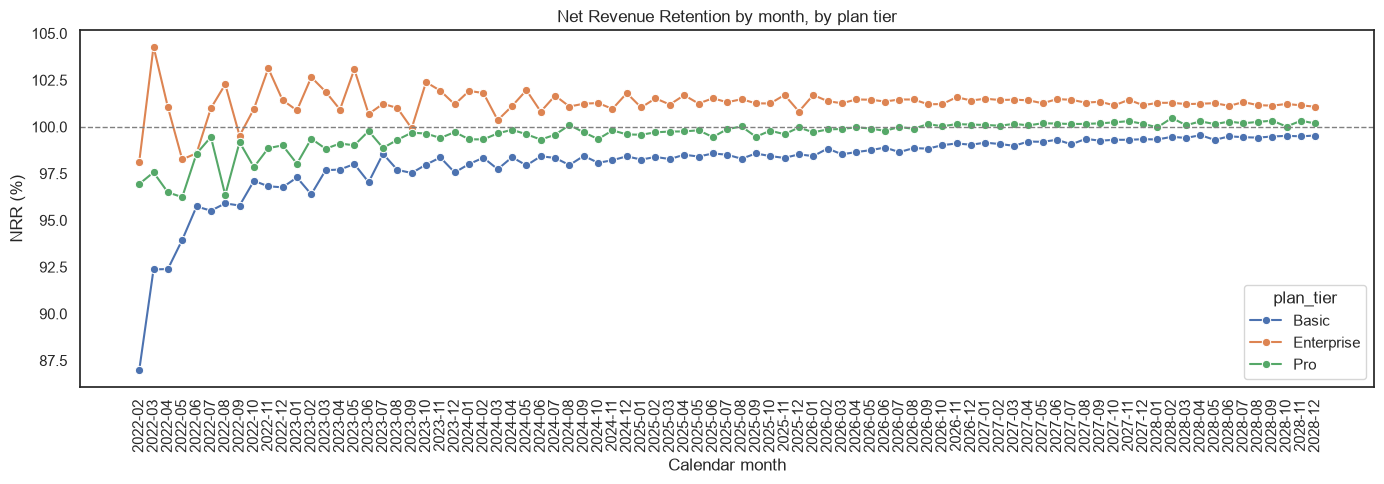

In [22]:
# 8b. NRR by calendar month, by plan tier
plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_nrr_by_plan_tier_long, x="calendar_month", y="nrr_percentage", hue="plan_tier", marker="o")
plt.axhline(100, color="gray", linestyle="--", linewidth=1)
plt.title("Net Revenue Retention by month, by plan tier")
plt.xlabel("Calendar month")
plt.ylabel("NRR (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 8c. NRR by month, by channel

In [23]:
# 8c. NRR by calendar month, by plan tier
monthly_nrr_by_channel_long = build_monthly_nrr_by_segment_long(customer_month_panel_dataframe, "channel")
monthly_nrr_by_channel_long

,calendar_month,channel,nrr_percentage
0,2022-02,Ads,97.031091
1,2022-03,Ads,99.661328
2,2022-04,Ads,97.726323
3,2022-05,Ads,95.546688
4,2022-06,Ads,92.434115
...,...,...,...
244,2028-08,Referral,101.378810
245,2028-09,Referral,101.623574
246,2028-10,Referral,101.478483
247,2028-11,Referral,101.553021


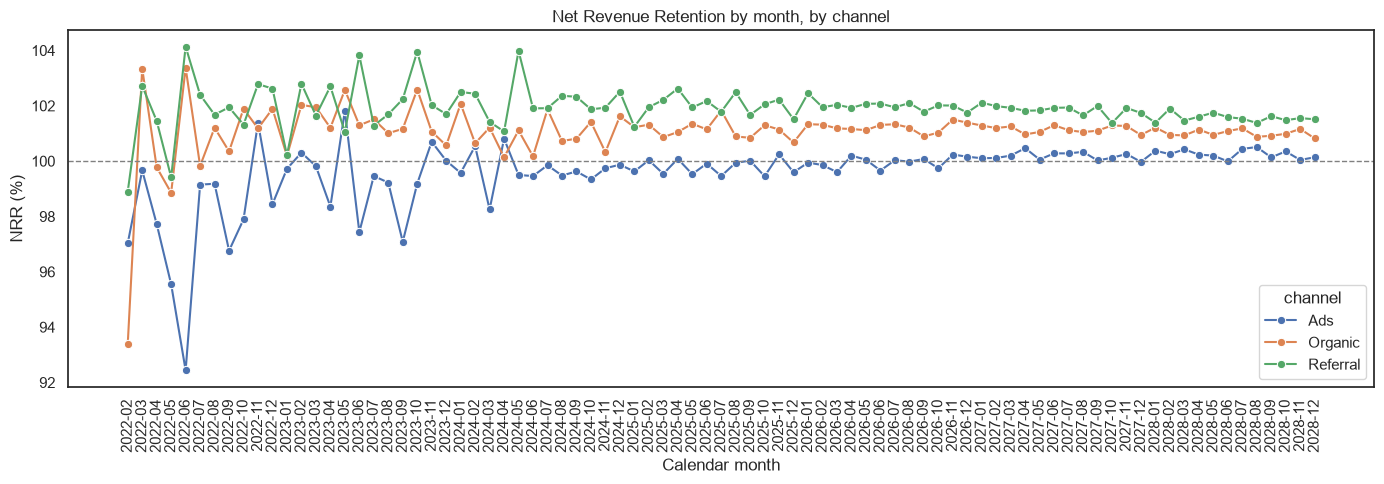

In [24]:
# 8c. NRR by calendar month, by plan tier
plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_nrr_by_channel_long, x="calendar_month", y="nrr_percentage", hue="channel", marker="o")
plt.axhline(100, color="gray", linestyle="--", linewidth=1)
plt.title("Net Revenue Retention by month, by channel")
plt.xlabel("Calendar month")
plt.ylabel("NRR (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 9. Total MRR by calendar month

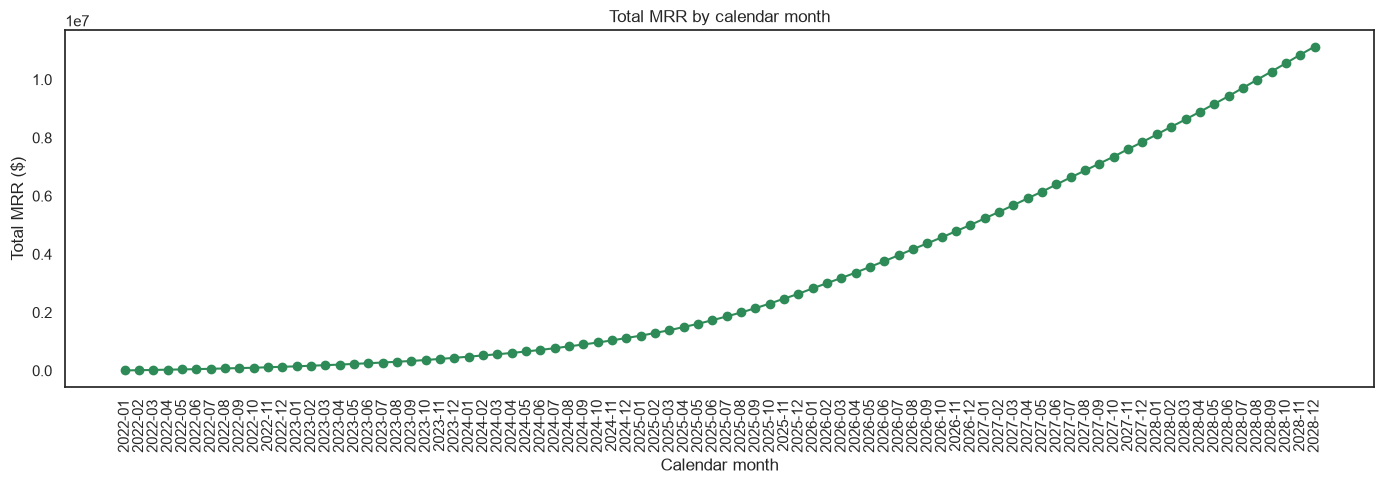

calendar_month
2022-01        7510.72
2022-02       15277.90
2022-03       24501.46
2022-04       33210.53
2022-05       41315.88
              ...     
2028-08     9993708.58
2028-09    10275152.87
2028-10    10559287.57
2028-11    10851806.46
2028-12    11129066.20
Name: mrr, Length: 84, dtype: float64

In [25]:
# 9. Total MRR by calendar month

def build_total_mrr_by_calendar_month(customer_month_panel_dataframe) -> pd.DataFrame:
    """Total company-wide MRR for every calendar month, blended across all segments."""
    return customer_month_panel_dataframe.groupby("calendar_month")["mrr"].sum().sort_index()


total_mrr_by_calendar_month_series = build_total_mrr_by_calendar_month(customer_month_panel_dataframe)

plt.figure(figsize=(14, 5))
plt.plot(total_mrr_by_calendar_month_series.index.astype(str), total_mrr_by_calendar_month_series.values,
          marker="o", color="seagreen")
plt.title("Total MRR by calendar month")
plt.xlabel("Calendar month")
plt.ylabel("Total MRR ($)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

total_mrr_by_calendar_month_series

## 10. Cohort retention curve

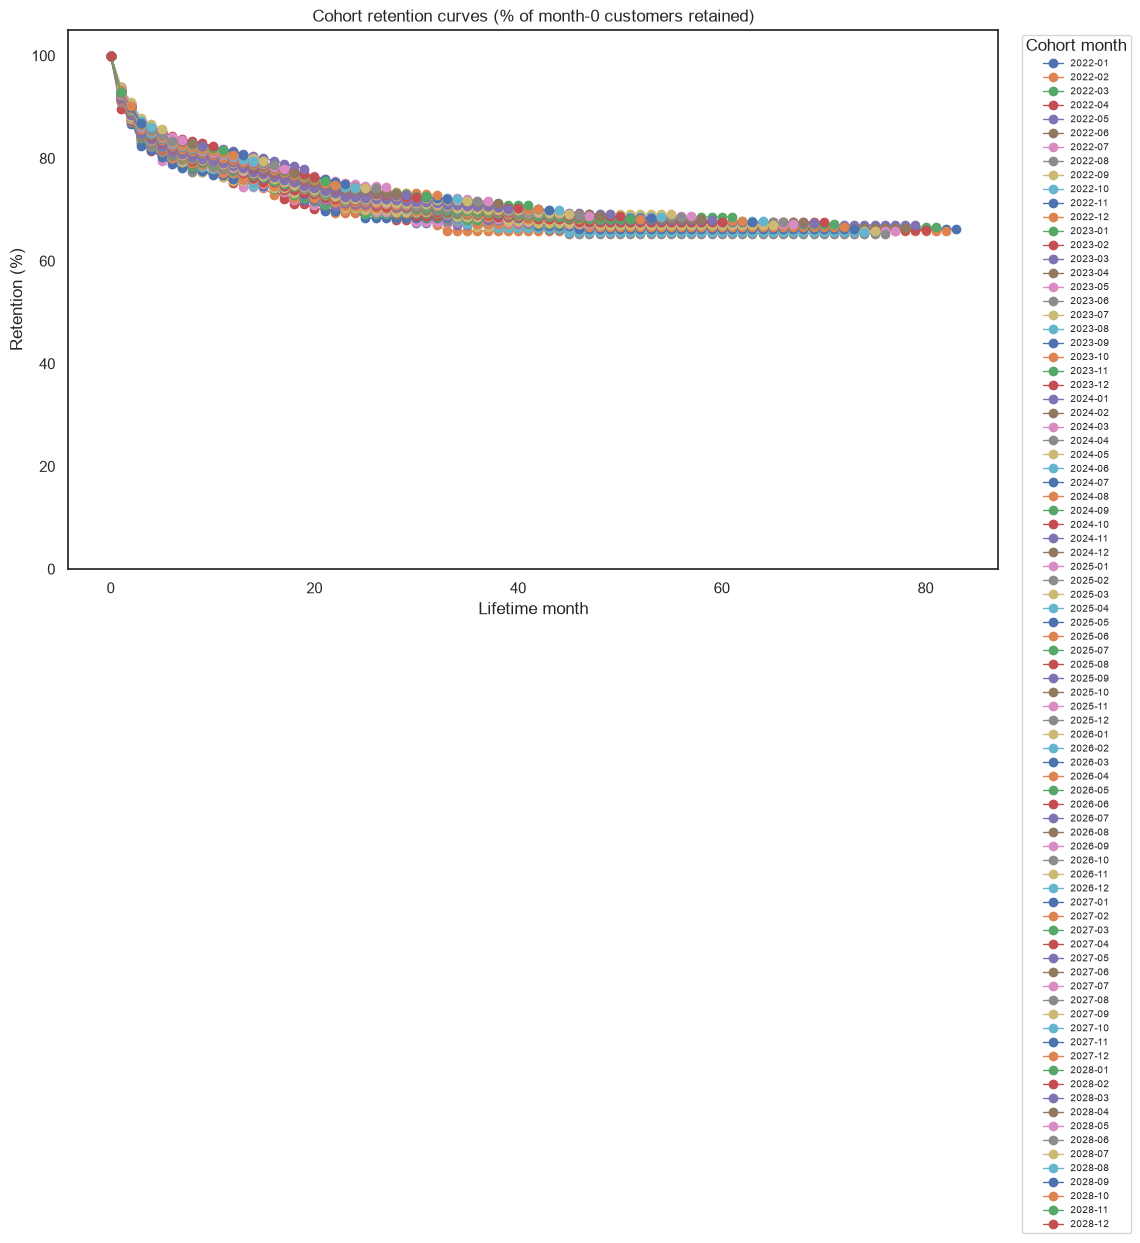

In [26]:
# 10. Cohort retention curve
blended_retention_percentage_grid = build_retention_percentage_grid(customer_month_panel_dataframe)

plt.figure(figsize=(12, 7))
for cohort_month_label, retention_row in blended_retention_percentage_grid.iterrows():
    retention_row_without_gaps = retention_row.dropna()
    plt.plot(
        retention_row_without_gaps.index, retention_row_without_gaps.values,
        marker="o", linewidth=1, label=cohort_month_label
    )

plt.title("Cohort retention curves (% of month-0 customers retained)")
plt.xlabel("Lifetime month")
plt.ylabel("Retention (%)")
plt.ylim(0, 105)
plt.legend(title="Cohort month", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
# plt.tight_layout()
plt.show()


## 11. Monthly churn rate

In [27]:
# 11. Monthly churn rate

def build_monthly_logo_churn_rate_table(customer_month_panel_dataframe) -> pd.DataFrame:
    """
    Build a monthly logo churn rate series.

    Compares customers active in month M-1 against the same customers in
    month M. A customer counts as churned in month M if they appeared in
    M-1 but do not appear at all in M. New signups in month M are not
    part of the denominator, since churn only applies to an existing base.

    churn_rate_M = customers active in M-1 but absent in M
                   / customers active in M-1 * 100

    Args:
        customer_month_panel_dataframe (pandas.DataFrame): the customer-month panel.

    Returns:
        pandas.DataFrame: calendar_month index, with columns
            "customers_at_start", "customers_churned", and
            "churn_rate_percentage".
    """
    active_customer_ids_by_month = (
        customer_month_panel_dataframe
        .groupby("calendar_month")["customer_id"]
        .apply(set)
    )
    sorted_calendar_month_columns = sorted(active_customer_ids_by_month.index)

    monthly_churn_rows = []
    for month_index in range(1, len(sorted_calendar_month_columns)):
        previous_month_text = sorted_calendar_month_columns[month_index - 1]
        current_month_text = sorted_calendar_month_columns[month_index]

        customers_active_previous_month = active_customer_ids_by_month[previous_month_text]
        customers_active_current_month = active_customer_ids_by_month[current_month_text]

        churned_customer_count = len(customers_active_previous_month - customers_active_current_month)
        starting_customer_count = len(customers_active_previous_month)

        monthly_churn_rows.append({
            "calendar_month": current_month_text,
            "customers_at_start": starting_customer_count,
            "customers_churned": churned_customer_count,
            "churn_rate_percentage": churned_customer_count / starting_customer_count * 100,
        })

    monthly_churn_rate_table = pd.DataFrame(monthly_churn_rows).set_index("calendar_month")
    return monthly_churn_rate_table



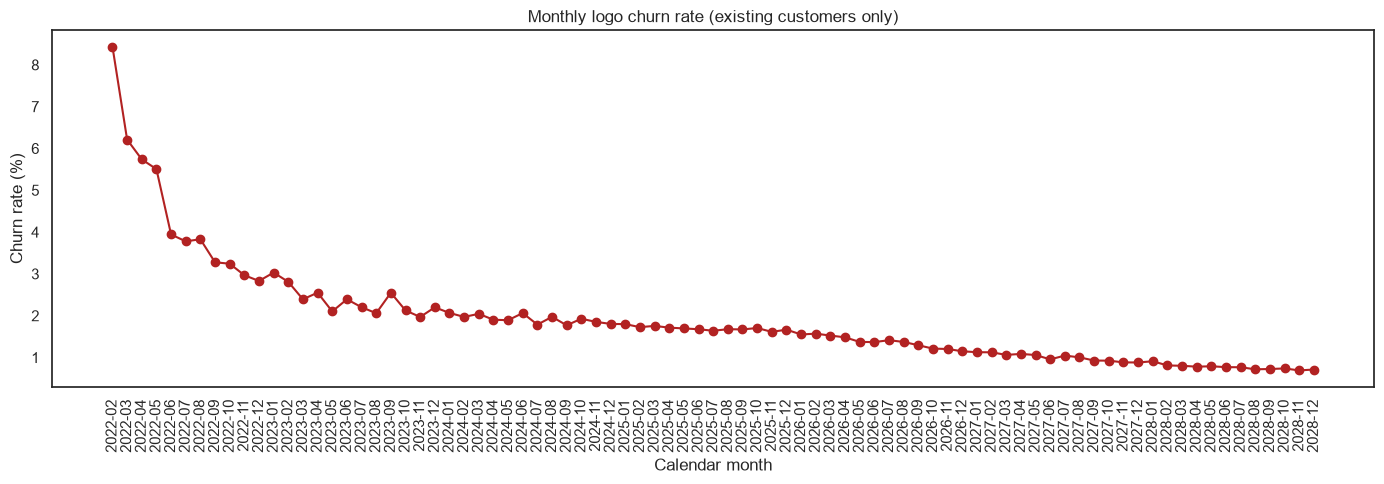

,customers_at_start,customers_churned,churn_rate_percentage
calendar_month,,,
2022-02,83,7,8.433735
2022-03,161,10,6.211180
2022-04,244,14,5.737705
2022-05,327,18,5.504587
2022-06,406,16,3.940887
...,...,...,...
2028-08,44794,321,0.716614
2028-09,45746,331,0.723561
2028-10,46672,344,0.737059


In [28]:
# 11. Monthly churn rate
monthly_churn_rate_table = build_monthly_logo_churn_rate_table(customer_month_panel_dataframe)

plt.figure(figsize=(14, 5))
plt.plot(
    monthly_churn_rate_table.index.astype(str), monthly_churn_rate_table["churn_rate_percentage"],
    marker="o", color="firebrick"
)
plt.title("Monthly logo churn rate (existing customers only)")
plt.xlabel("Calendar month")
plt.ylabel("Churn rate (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

monthly_churn_rate_table


## 12. Cohort retention heatmap

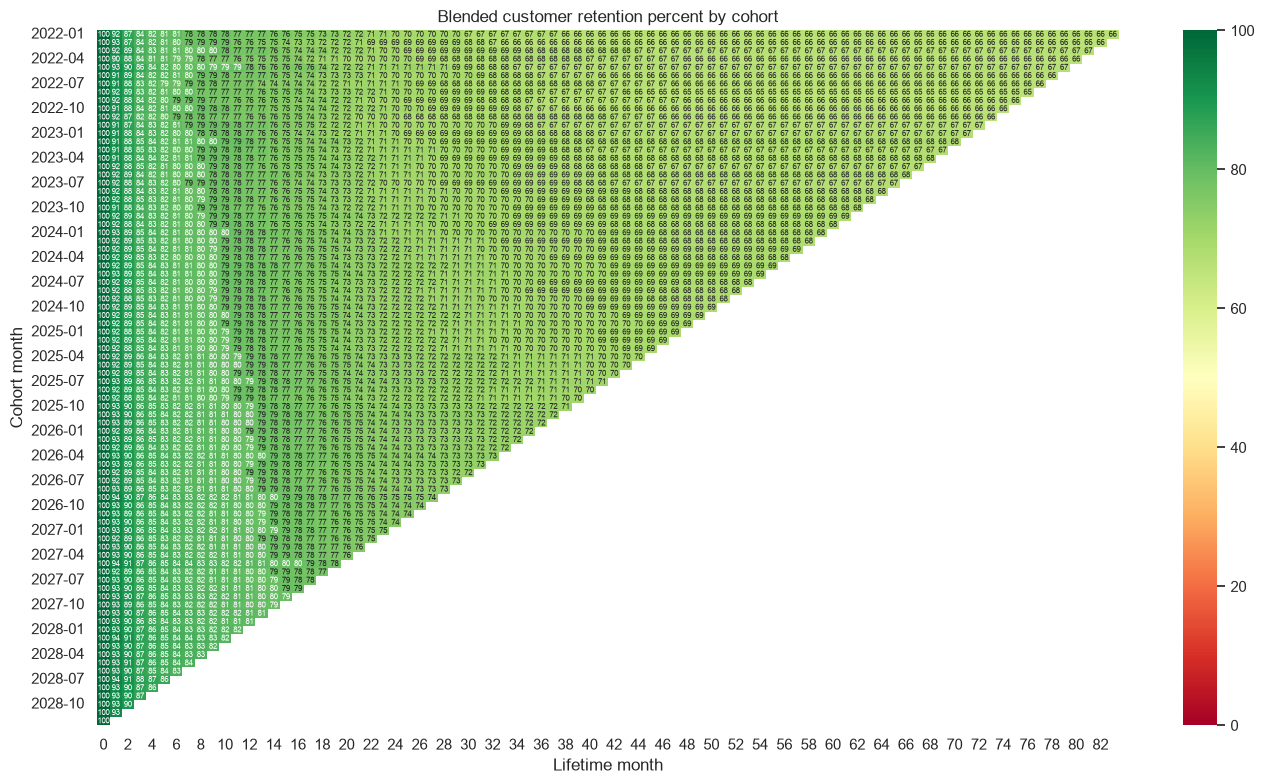

lifetime_month,0,1,2,3,4,5,6,7,8,9,...,74,75,76,77,78,79,80,81,82,83
cohort_month,,,,,,,,,,,,,,,,,,,,,
2022-01,100.0,91.566265,86.746988,84.337349,81.927711,80.722892,80.722892,78.313253,78.313253,78.313253,...,66.265060,66.265060,66.265060,66.265060,66.265060,66.265060,66.265060,66.265060,66.265060,66.26506
2022-02,100.0,92.941176,87.058824,83.529412,82.352941,81.176471,80.000000,78.823529,78.823529,78.823529,...,65.882353,65.882353,65.882353,65.882353,65.882353,65.882353,65.882353,65.882353,65.882353,NaN
2022-03,100.0,92.473118,89.247312,83.870968,82.795699,80.645161,80.645161,79.569892,79.569892,79.569892,...,66.666667,66.666667,66.666667,66.666667,66.666667,66.666667,66.666667,66.666667,NaN,NaN
2022-04,100.0,89.690722,87.628866,83.505155,81.443299,81.443299,79.381443,79.381443,78.350515,77.319588,...,65.979381,65.979381,65.979381,65.979381,65.979381,65.979381,65.979381,NaN,NaN,NaN
2022-05,100.0,92.783505,89.690722,85.567010,83.505155,82.474227,80.412371,80.412371,80.412371,79.381443,...,67.010309,67.010309,67.010309,67.010309,67.010309,67.010309,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2028-08,100.0,93.322859,90.259230,87.195601,86.174391,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2028-09,100.0,92.919650,90.055688,86.793954,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2028-10,100.0,93.235534,90.138549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# 12. Cohort retention heatmap
blended_retention_percentage_grid_for_heatmap = build_retention_percentage_grid(customer_month_panel_dataframe)

plt.figure(figsize=(14, 8))
sns.heatmap(
    blended_retention_percentage_grid_for_heatmap, cmap="RdYlGn", vmin=0, vmax=100,
    annot=True, fmt=".0f", annot_kws={"size": 6}
)
plt.title("Blended customer retention percent by cohort")
plt.xlabel("Lifetime month")
plt.ylabel("Cohort month")
plt.tight_layout()
plt.show()

blended_retention_percentage_grid_for_heatmap


## 13. Price parity by channel within plan tier (v9_2 check)

The v9_2 generator charges every channel the same list price within a plan tier.
Average month-0 MRR should therefore be almost identical across Ads, Organic,
and Referral inside each plan. This section checks that the generated data has
no price gap between channels.

Base price is approximated as average month-0 MRR (before any expansion has had
a chance to apply), split by channel and plan tier. A channel is flagged if its
average sits more than 1.05x above or below another channel in the same tier.

Average month-0 MRR (proxy for base ARPU), by plan tier and channel


channel,Ads,Organic,Referral
plan_tier,,,
Basic,19.80,19.81,19.82
Enterprise,593.87,593.88,593.04
Pro,59.36,59.42,59.39



Parity check (ratio of each channel's ARPU against the other two in its tier)
Basic       Ads       max ratio vs other channels: 1.00x -- OK
Basic       Organic   max ratio vs other channels: 1.00x -- OK
Basic       Referral  max ratio vs other channels: 1.00x -- OK
Enterprise  Ads       max ratio vs other channels: 1.00x -- OK
Enterprise  Organic   max ratio vs other channels: 1.00x -- OK
Enterprise  Referral  max ratio vs other channels: 1.00x -- OK
Pro         Ads       max ratio vs other channels: 1.00x -- OK
Pro         Organic   max ratio vs other channels: 1.00x -- OK
Pro         Referral  max ratio vs other channels: 1.00x -- OK


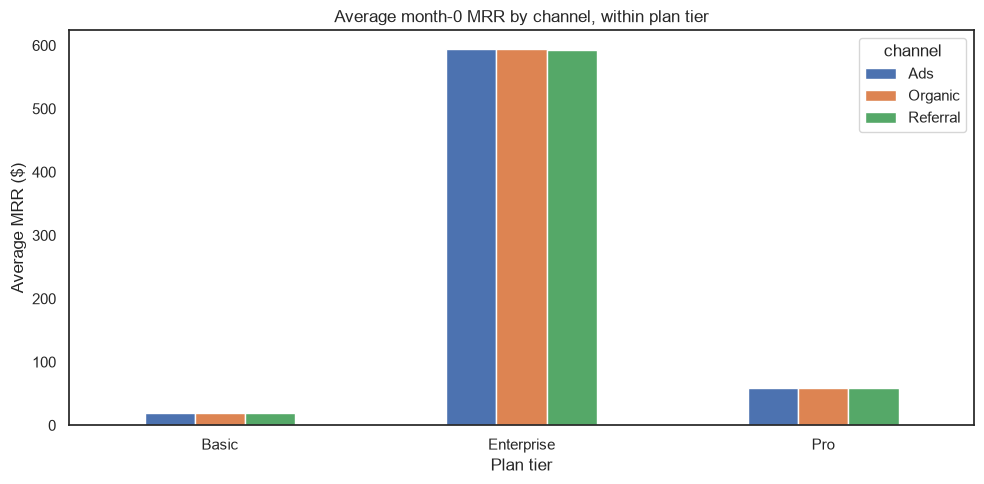

In [30]:
# 13. Price parity by channel within plan tier
month_zero_rows = customer_month_panel_dataframe[customer_month_panel_dataframe["lifetime_month"] == 0]
arpu_parity_table = (
    month_zero_rows
    .groupby(["plan_tier", "channel"])["mrr"]
    .mean()
    .unstack("channel")
    .round(2)
)

print("Average month-0 MRR (proxy for base ARPU), by plan tier and channel")
display(arpu_parity_table)

print()
print("Parity check (ratio of each channel's ARPU against the other two in its tier)")
for plan_tier_name, row in arpu_parity_table.iterrows():
    channel_values = row.dropna()
    for channel_name in channel_values.index:
        other_channels = channel_values.drop(channel_name)
        worst_ratio = (channel_values[channel_name] / other_channels).abs().max()
        worst_ratio = max(worst_ratio, 1 / worst_ratio) if worst_ratio < 1 else worst_ratio
        status_label = "OK" if worst_ratio <= 1.05 else "FLAG: outside 1.05x parity band"
        print(f"{plan_tier_name:12s}{channel_name:10s}max ratio vs other channels: {worst_ratio:.2f}x -- {status_label}")

plt.figure(figsize=(10, 5))
arpu_parity_table.plot(kind="bar", ax=plt.gca())
plt.title("Average month-0 MRR by channel, within plan tier")
plt.xlabel("Plan tier")
plt.ylabel("Average MRR ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 14. What stopping Ads would cost

This section takes one channel out of the business and shows what changes. Set `channel_to_stop` and `gross_margin_fraction` in cell 14a.

Contents:
- 14a. What the channel brought in and what it cost, to date.
- 14b. The business with and without the channel: customers, revenue, spending, and the CLV:CAC ratio.
- 14c. A running total of money kept minus money spent, by channel.
- 14d and 14e. How many months a new customer takes to pay back their acquisition cost.

Assumptions and limitations:
- It assumes every other channel carries on exactly as before. In a real business, some Organic and Referral customers may have first seen an ad. This dataset has no link between channels, so that effect is not measured.
- It says nothing about direct selling. This dataset has no direct sales channel.
- Revenue counts in full unless `gross_margin_fraction` is set below 1.

In [31]:
# 14a. What each channel has brought in and what it cost
channel_to_stop = "Ads"
gross_margin_fraction = 1.0  # 1.0 counts revenue only. Try 0.75 to allow for the cost of running the service.


def build_channel_contribution_table(customer_month_panel_dataframe, cost_per_customer_dataframe,
                                     gross_margin_fraction=1.0) -> pd.DataFrame:
    """
    Build one row per channel showing what it has brought in and what it cost.

    kept_revenue_dollars is revenue collected times gross_margin_fraction,
    the part left after the cost of running the service. The
    net_after_acquisition_dollars column is kept revenue minus the money
    spent to acquire the customers.

    Args:
        customer_month_panel_dataframe (pandas.DataFrame): the customer-month panel.
        cost_per_customer_dataframe (pandas.DataFrame): the cost-per-customer table.
        gross_margin_fraction (float): share of revenue that is kept, from 0 to 1.

    Returns:
        pandas.DataFrame: one row per channel.
    """
    last_calendar_month_text = customer_month_panel_dataframe["calendar_month"].max()
    last_month_rows = customer_month_panel_dataframe[
        customer_month_panel_dataframe["calendar_month"] == last_calendar_month_text
    ]

    contribution_table = pd.DataFrame({
        "customers_acquired": cost_per_customer_dataframe.groupby("channel")["new_customers"].sum(),
        "acquisition_spend_dollars": cost_per_customer_dataframe.groupby("channel")["total_acquisition_cost_dollars"].sum(),
        "revenue_collected_dollars": customer_month_panel_dataframe.groupby("channel")["mrr"].sum(),
        "active_customers_last_month": last_month_rows.groupby("channel")["customer_id"].nunique(),
        "monthly_revenue_last_month_dollars": last_month_rows.groupby("channel")["mrr"].sum(),
    })
    contribution_table["kept_revenue_dollars"] = contribution_table["revenue_collected_dollars"] * gross_margin_fraction
    contribution_table["net_after_acquisition_dollars"] = (
        contribution_table["kept_revenue_dollars"] - contribution_table["acquisition_spend_dollars"]
    )
    contribution_table["share_of_customers_acquired"] = (
        contribution_table["customers_acquired"] / contribution_table["customers_acquired"].sum()
    )
    contribution_table["share_of_revenue_collected"] = (
        contribution_table["revenue_collected_dollars"] / contribution_table["revenue_collected_dollars"].sum()
    )
    contribution_table["share_of_last_month_revenue"] = (
        contribution_table["monthly_revenue_last_month_dollars"] / contribution_table["monthly_revenue_last_month_dollars"].sum()
    )
    return contribution_table.round(3)


channel_contribution_table = build_channel_contribution_table(
    customer_month_panel_dataframe, cost_per_customer_dataframe, gross_margin_fraction
)

stopped_row = channel_contribution_table.loc[channel_to_stop]
print(f"{channel_to_stop} brought in {stopped_row['share_of_customers_acquired']:.0%} of customers "
      f"and {stopped_row['share_of_revenue_collected']:.0%} of revenue collected so far.")
print(f"{channel_to_stop} is {stopped_row['share_of_last_month_revenue']:.0%} of the latest month's revenue.")
print(f"It cost ${stopped_row['acquisition_spend_dollars']:,.0f} to acquire its customers "
      f"and kept ${stopped_row['kept_revenue_dollars']:,.0f} in revenue, "
      f"leaving ${stopped_row['net_after_acquisition_dollars']:,.0f}.")

channel_contribution_table.to_csv("helper_dfs/channel_contribution.csv")
channel_contribution_table

Ads brought in 40% of customers and 34% of revenue collected so far.
Ads is 31% of the latest month's revenue.
It cost $17,009,715 to acquire its customers and kept $94,213,788 in revenue, leaving $77,204,073.


,customers_acquired,acquisition_spend_dollars,revenue_collected_dollars,active_customers_last_month,monthly_revenue_last_month_dollars,kept_revenue_dollars,net_after_acquisition_dollars,share_of_customers_acquired,share_of_revenue_collected,share_of_last_month_revenue
channel,,,,,,,,,,
Ads,25974,17009714.87,9.421379e+07,15700,3456856.02,9.421379e+07,77204073.49,0.400,0.342,0.311
Organic,17318,4558819.33,7.851623e+07,13874,3085845.79,7.851623e+07,73957414.96,0.267,0.285,0.277
Referral,21649,11591413.28,1.026882e+08,19780,4586364.39,1.026882e+08,91096762.19,0.333,0.373,0.412


In [32]:
# 14b. The business with and without the channel
def build_with_and_without_table(channel_contribution_table, channel_to_stop,
                                 customer_month_panel_dataframe, cost_per_customer_dataframe, clv_month_count) -> pd.DataFrame:
    """
    Compare the whole business with the same business minus one channel.

    Every other channel is assumed to carry on exactly as before. The last
    row is the CLV:CAC ratio, using the same clv_month_count window as Section 7.

    Args:
        channel_contribution_table (pandas.DataFrame): output of build_channel_contribution_table.
        channel_to_stop (str): the channel to remove, for example "Ads".
        customer_month_panel_dataframe (pandas.DataFrame): the customer-month panel.
        cost_per_customer_dataframe (pandas.DataFrame): the cost-per-customer table.
        clv_month_count (int): months of customer life counted toward CLV.

    Returns:
        pandas.DataFrame: rows are measures, columns are "All channels",
            "Without <channel>", the change, and the percent change.
    """
    measure_column_name_list = [
        "customers_acquired", "acquisition_spend_dollars", "revenue_collected_dollars",
        "net_after_acquisition_dollars", "monthly_revenue_last_month_dollars", "active_customers_last_month",
    ]
    all_channels_totals = channel_contribution_table[measure_column_name_list].sum()
    without_channel_totals = channel_contribution_table.drop(index=channel_to_stop)[measure_column_name_list].sum()

    scope_panel_dataframe = pd.concat([
        customer_month_panel_dataframe.assign(scope="All channels"),
        customer_month_panel_dataframe[customer_month_panel_dataframe["channel"] != channel_to_stop].assign(scope="Without channel"),
    ])
    scope_cost_dataframe = pd.concat([
        cost_per_customer_dataframe.assign(scope="All channels"),
        cost_per_customer_dataframe[cost_per_customer_dataframe["channel"] != channel_to_stop].assign(scope="Without channel"),
    ])
    scope_ratio_table = build_clv_cac_ratio_table(scope_panel_dataframe, scope_cost_dataframe, ["scope"], clv_month_count)
    all_channels_totals["clv_to_cac_ratio"] = scope_ratio_table.loc["All channels", "clv_to_cac_ratio"]
    without_channel_totals["clv_to_cac_ratio"] = scope_ratio_table.loc["Without channel", "clv_to_cac_ratio"]

    with_and_without_table = pd.DataFrame({
        "All channels": all_channels_totals,
        f"Without {channel_to_stop}": without_channel_totals,
    })
    with_and_without_table["Change if stopped"] = with_and_without_table.iloc[:, 1] - with_and_without_table.iloc[:, 0]
    with_and_without_table["Percent change"] = (
        with_and_without_table["Change if stopped"] / with_and_without_table["All channels"] * 100
    )
    return with_and_without_table.round(2)


with_and_without_table = build_with_and_without_table(
    channel_contribution_table, channel_to_stop,
    customer_month_panel_dataframe, cost_per_customer_dataframe, clv_month_count,
)
with_and_without_table.to_csv(f"helper_dfs/with_and_without_{channel_to_stop}.csv")
with_and_without_table

last_calendar_month_ordinal 
 707


cohort_months_observable_lookup 
 {'2022-01': 83, '2022-02': 82, '2022-03': 81, '2022-04': 80, '2022-05': 79, '2022-06': 78, '2022-07': 77, '2022-08': 76, '2022-09': 75, '2022-10': 74, '2022-11': 73, '2022-12': 72, '2023-01': 71, '2023-02': 70, '2023-03': 69, '2023-04': 68, '2023-05': 67, '2023-06': 66, '2023-07': 65, '2023-08': 64, '2023-09': 63, '2023-10': 62, '2023-11': 61, '2023-12': 60, '2024-01': 59, '2024-02': 58, '2024-03': 57, '2024-04': 56, '2024-05': 55, '2024-06': 54, '2024-07': 53, '2024-08': 52, '2024-09': 51, '2024-10': 50, '2024-11': 49, '2024-12': 48, '2025-01': 47, '2025-02': 46, '2025-03': 45, '2025-04': 44, '2025-05': 43, '2025-06': 42, '2025-07': 41, '2025-08': 40, '2025-09': 39, '2025-10': 38, '2025-11': 37, '2025-12': 36, '2026-01': 35, '2026-02': 34, '2026-03': 33, '2026-04': 32, '2026-05': 31, '2026-06': 30, '2026-07': 29, '2026-08': 28, '2026-09': 27, '2026-10': 26, '2026-11': 25, '2026-12': 24, '2027-01': 23, '2027-02': 22,

,All channels,Without Ads,Change if stopped,Percent change
customers_acquired,6.494100e+04,3.896700e+04,-25974.00,-40.00
acquisition_spend_dollars,3.315995e+07,1.615023e+07,-17009714.87,-51.30
revenue_collected_dollars,2.754182e+08,1.812044e+08,-94213788.36,-34.21
net_after_acquisition_dollars,2.422583e+08,1.650542e+08,-77204073.49,-31.87
monthly_revenue_last_month_dollars,1.112907e+07,7.672210e+06,-3456856.02,-31.06
active_customers_last_month,4.935400e+04,3.365400e+04,-15700.00,-31.81
clv_to_cac_ratio,6.700000e+00,9.170000e+00,2.47,36.87


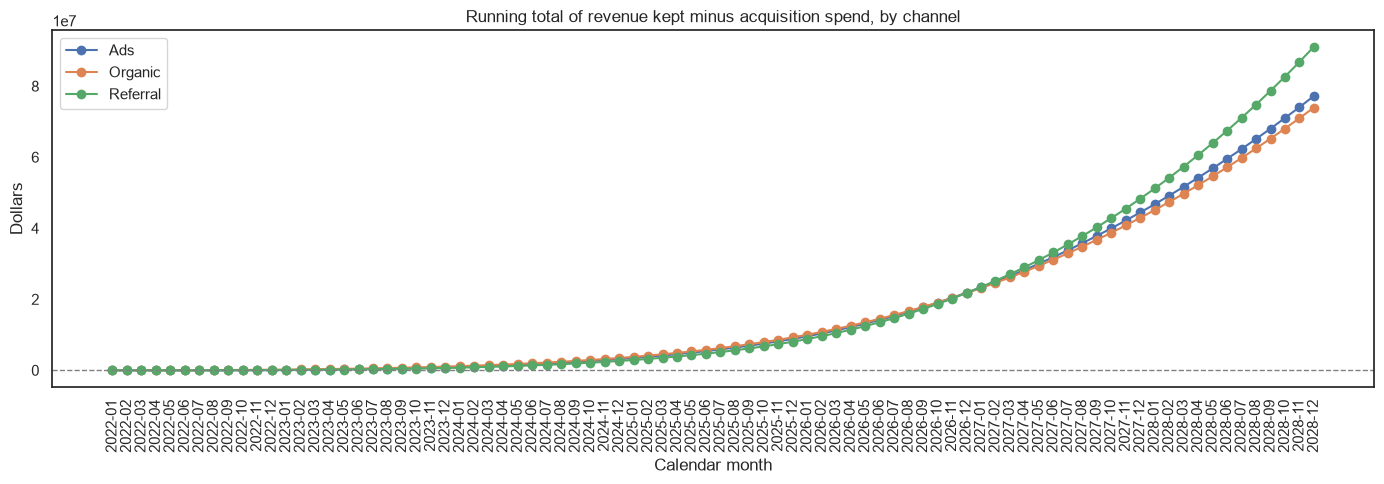

Ads: first month the running total is above zero = 2022-12, latest running total = $77,204,073
Organic: first month the running total is above zero = 2022-04, latest running total = $73,957,415
Referral: first month the running total is above zero = 2022-08, latest running total = $91,096,762


In [33]:
# 14c. Running total of money in minus money spent, by channel
revenue_by_channel_and_month = (
    customer_month_panel_dataframe.groupby(["calendar_month", "channel"])["mrr"].sum().unstack("channel").fillna(0)
) * gross_margin_fraction
spend_by_channel_and_month = (
    cost_per_customer_dataframe.groupby(["cohort_month", "channel"])["total_acquisition_cost_dollars"].sum()
    .unstack("channel").reindex(revenue_by_channel_and_month.index).fillna(0)
)
running_net_by_channel = (revenue_by_channel_and_month - spend_by_channel_and_month).cumsum()

plt.figure(figsize=(14, 5))
for channel_name in running_net_by_channel.columns:
    plt.plot(running_net_by_channel.index.astype(str), running_net_by_channel[channel_name], marker="o", label=channel_name)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Running total of revenue kept minus acquisition spend, by channel")
plt.xlabel("Calendar month")
plt.ylabel("Dollars")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

for channel_name in running_net_by_channel.columns:
    positive_months = running_net_by_channel[running_net_by_channel[channel_name] > 0]
    turned_positive_text = positive_months.index[0] if len(positive_months) else "not yet"
    print(f"{channel_name}: first month the running total is above zero = {turned_positive_text}, "
          f"latest running total = ${running_net_by_channel[channel_name].iloc[-1]:,.0f}")

In [34]:
# 14d. Months to earn back the cost of acquiring a customer
def build_months_to_earn_back_table(customer_month_panel_dataframe, cost_per_customer_dataframe,
                                    group_column_name_list=("channel",), month_count=24,
                                    gross_margin_fraction=1.0):
    """
    Find how many months of life it takes for a new customer to pay back
    what it cost to acquire them.

    Revenue per customer is built one month of life at a time, the same way
    as the CLV in Section 7. Each month's average uses every cohort that has
    reached that month. The running total is compared against blended CAC.

    Args:
        customer_month_panel_dataframe (pandas.DataFrame): the customer-month panel.
        cost_per_customer_dataframe (pandas.DataFrame): the cost-per-customer table.
        group_column_name_list (list of str): columns to group by.
        month_count (int): how many months of life to look at.
        gross_margin_fraction (float): share of revenue that is kept, from 0 to 1.

    Returns:
        pandas.DataFrame: one row per group with CAC, the months to earn it
            back (or a note if it takes longer than month_count), and the
            kept revenue per customer at 12 and at month_count months.
    """
    group_columns = list(group_column_name_list)
    last_calendar_month_number = pd.Period(customer_month_panel_dataframe["calendar_month"].max(), freq="M").ordinal
    cohort_months_observable_lookup = {
        cohort_month_text: last_calendar_month_number - pd.Period(cohort_month_text, freq="M").ordinal
        for cohort_month_text in customer_month_panel_dataframe["cohort_month"].unique()
    }

    starting_customer_table = (
        customer_month_panel_dataframe[customer_month_panel_dataframe["lifetime_month"] == 0]
        .groupby(group_columns + ["cohort_month"])["customer_id"].nunique()
        .reset_index(name="starting_customer_count")
    )
    starting_customer_table["months_observable"] = starting_customer_table["cohort_month"].map(cohort_months_observable_lookup)
    revenue_table = (
        customer_month_panel_dataframe.groupby(group_columns + ["lifetime_month"])["mrr"].sum()
        .reset_index(name="revenue_dollars")
    )

    monthly_average_revenue_series_list = []
    for lifetime_month_number in range(month_count):
        cohorts_that_reached_month = starting_customer_table[starting_customer_table["months_observable"] >= lifetime_month_number]
        starting_customers_by_group = cohorts_that_reached_month.groupby(group_columns)["starting_customer_count"].sum()
        revenue_by_group = (
            revenue_table[revenue_table["lifetime_month"] == lifetime_month_number]
            .set_index(group_columns)["revenue_dollars"]
        )
        monthly_average_revenue_series_list.append((revenue_by_group / starting_customers_by_group).fillna(0))
    running_revenue_per_customer = pd.concat(monthly_average_revenue_series_list, axis=1).cumsum(axis=1) * gross_margin_fraction
    running_revenue_per_customer.columns = range(1, month_count + 1)

    cost_totals = cost_per_customer_dataframe.groupby(group_columns).agg(
        total_acquisition_cost_dollars=("total_acquisition_cost_dollars", "sum"),
        customers_acquired=("new_customers", "sum"),
    )
    blended_cac_series = cost_totals["total_acquisition_cost_dollars"] / cost_totals["customers_acquired"]

    earned_back_flags = running_revenue_per_customer.ge(blended_cac_series, axis=0)
    first_month_earned_back = earned_back_flags.idxmax(axis=1).where(earned_back_flags.any(axis=1))

    months_to_earn_back_table = pd.DataFrame({
        "blended_cac_dollars": blended_cac_series,
        "months_to_earn_back": first_month_earned_back.map(
            lambda month_value: f"not within {month_count} months" if pd.isna(month_value) else int(month_value)
        ),
        "kept_revenue_per_customer_at_12_months": running_revenue_per_customer[12] if month_count >= 12 else None,
        f"kept_revenue_per_customer_at_{month_count}_months": running_revenue_per_customer[month_count],
    })
    return months_to_earn_back_table.round(2)


months_to_earn_back_by_channel = build_months_to_earn_back_table(
    customer_month_panel_dataframe, cost_per_customer_dataframe, ["channel"], clv_month_count, gross_margin_fraction
)
months_to_earn_back_by_channel.to_csv("helper_dfs/months_to_earn_back_by_channel.csv")
months_to_earn_back_by_channel

,blended_cac_dollars,months_to_earn_back,kept_revenue_per_customer_at_12_months,kept_revenue_per_customer_at_24_months
channel,,,,
Ads,654.87,6,1428.85,2879.15
Organic,263.24,3,1599.67,3517.05
Referral,535.42,4,1765.69,4049.38


In [35]:
# 14e. Months to earn back the cost of acquiring a customer, by channel and plan tier
months_to_earn_back_by_segment = build_months_to_earn_back_table(
    customer_month_panel_dataframe, cost_per_customer_dataframe, ["channel", "plan_tier"],
    clv_month_count, gross_margin_fraction
)
months_to_earn_back_by_segment.to_csv("helper_dfs/months_to_earn_back_by_channel_and_plan_tier.csv")
months_to_earn_back_by_segment

blended_cac_dollars  months_to_earn_back  \
channel  plan_tier                                              
Ads      Basic                     99.84                    7   
         Enterprise              3001.07                    6   
         Pro                      300.30                    6   
Organic  Basic                     39.88                    3   
         Enterprise              1201.69                    3   
         Pro                      119.88                    3   
Referral Basic                     79.95                    5   
         Enterprise              2403.27                    4   
         Pro                      239.43                    5   

                     kept_revenue_per_customer_at_12_months  \
channel  plan_tier                                            
Ads      Basic                                       178.91   
         Enterprise                                 6928.25   
         Pro                                         598.34   
Organic  Basic                                       201.09   
         Enterprise                                 7721.19   
         Pro                                         669.17   
Referral Basic                                       219.73   
         Enterprise                                 8363.37   
         Pro                                         739.55   

                     kept_revenue_per_customer_at_24_months  
channel  plan_tier                                           
Ads      Basic                                       325.81  
         Enterprise                                14540.37  
         Pro                                        1155.41  
Organic  Basic                                       399.42  
         Enterprise                                17728.02  
         Pro                                        1409.28  
Referral Basic                                       446.31  
         Enterprise                                20159.60  
         Pro                                        1609.07